## NX-414: Brain-like computation and intelligence
Project made by Sophie Mosegaard, Valentine Voigt, Daniel Bach.

### Notes before running the jupyter:

This jupyter notebook contains all the models tested. Namely
- Linear Regression with and without PCA
- Ridge Regression with and without PCA
- ResNet50
- a Shallow CNN
- VGG16 with and without object recognition
- Vision Transformer

Please note that running this script takes about 3h with 128G RAM.

The best model found when considering the pearson correlation and the explained variance is the VGG16 model that does not contain the object recognition. Additionally, this notebook contains all the created figures and results, as well as all the hyperparametertuning. Some datasets may be reloaded in the code for a new model, since the models were created by different students and then combined to follow the project submission guidelines.

All the necessary imports are listed after the dataloading provided by the project description.

### Data loading as provided

In [1]:
import sys
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/vvoigt/Documents/NX/NX-414-Project/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
# from utils import load_it_data, visualize_img
### Utils
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np


def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return

import matplotlib.pyplot as plt
import numpy as np
import gdown
import os
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
if not os.path.exists(output):
    gdown.download(url, output, quiet=False, fuzzy=True)


In [3]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [4]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The train dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The train dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


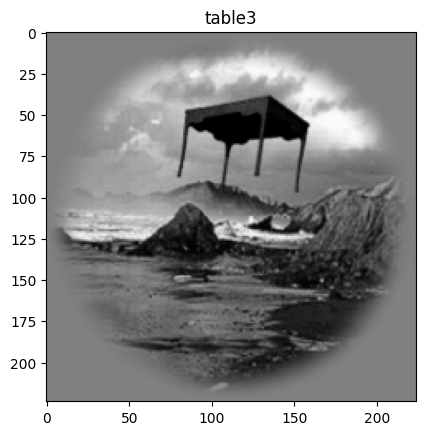

In [5]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

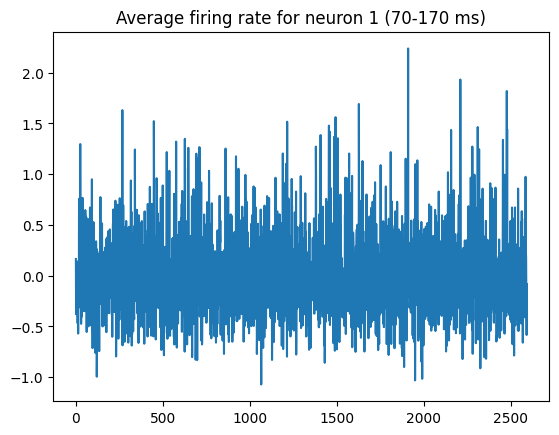

In [6]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

### All the necessary imports and setting the seed for reproducability

In [7]:
import numpy as np
import random
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score, accuracy_score, r2_score
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import models
from tqdm import tqdm
import timm
import optuna
import warnings
from sklearn.preprocessing import LabelEncoder
import torch.utils.data as data
from torchvision.models import resnet50, ResNet50_Weights
import pickle

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) 

# Week 6: Linear Regression and Ridge regression

## Part 1:

In [9]:
# Reshape the data
X_train = stimulus_train.reshape(stimulus_train.shape[0], -1)
X_val = stimulus_val.reshape(stimulus_val.shape[0], -1)
X_test = stimulus_test.reshape(stimulus_test.shape[0], -1)
y_train = spikes_train.reshape(spikes_train.shape[0], -1)
y_val = spikes_val.reshape(spikes_val.shape[0], -1)

In [10]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
def evaluate_model(model, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Evaluate a model using Pearson correlation and explained variance.

    Parameters:
    - model: Trained model with a `predict` method.
    - X (np.ndarray): Input data of shape (n_samples, n_features).
    - y (np.ndarray): True output data of shape (n_samples, n_targets).

    Returns:
    - tuple[np.ndarray, np.ndarray]: A tuple containing:
        - corr (np.ndarray): Pearson correlation for each output dimension, shape (n_targets,).
        - evar (np.ndarray): Explained variance for each output dimension, shape (n_targets,).
    """

    # Predict the output using the model
    y_pred = model.predict(X)

    # Compute Pearson correlation for all dimensions
    corr = np.array([pearsonr(y[:, i], y_pred[:, i])[0] for i in range(y.shape[1])])

    # Compute explained variance for all dimensions
    evar = explained_variance_score(y, y_pred, multioutput='raw_values')

    return corr, evar

In [ ]:
def plot_ev_distributions(ev_list: list[np.ndarray], models: list[str], kde:bool=True) -> None:
    """
    Plot the distribution of explained variance (ev) across neurons for multiple models.

    Parameters:
    - ev_list (list[np.ndarray]): List of arrays of explained variance values for each neuron, one per model.
    - model_names (list[str]): List of model names corresponding to the EV arrays.
    - kde (bool): If True, use Kernel Density Estimation for visualization.
    """
    plt.figure(figsize=(12, 6))
    for ev, model in zip(ev_list, models):
        if kde:
            sns.kdeplot(ev, label=model, fill=True, alpha=0.5)
        else:
            plt.hist(ev, bins=30, alpha=0.7, label=model, edgecolor='black')
    title = "Distribution of explained variance across neurons"
    if len(models) == 1:
        title += f" - {models[0]}"
    plt.title(title)
    plt.xlabel("Explained variance")
    plt.ylabel("Number of neurons")
    plt.legend()
    plt.grid(alpha=0.75)
    plt.show()

##### Linear Regression

In [13]:
linear = LinearRegression()
linear.fit(X_train, y_train)

LinearRegression()

In [14]:
# Results
corr_linear, ev_linear = evaluate_model(linear, X_val, y_val)
mean_corr_linear, mean_ev_linear = np.mean(corr_linear), np.mean(ev_linear)
model_linear = "Linear Regression"
print(model_linear)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear))
print("Mean explained variance: {:.4f}".format(mean_ev_linear))

Linear Regression
Mean pearson correlation: 0.2203
Mean explained variance: -0.0374


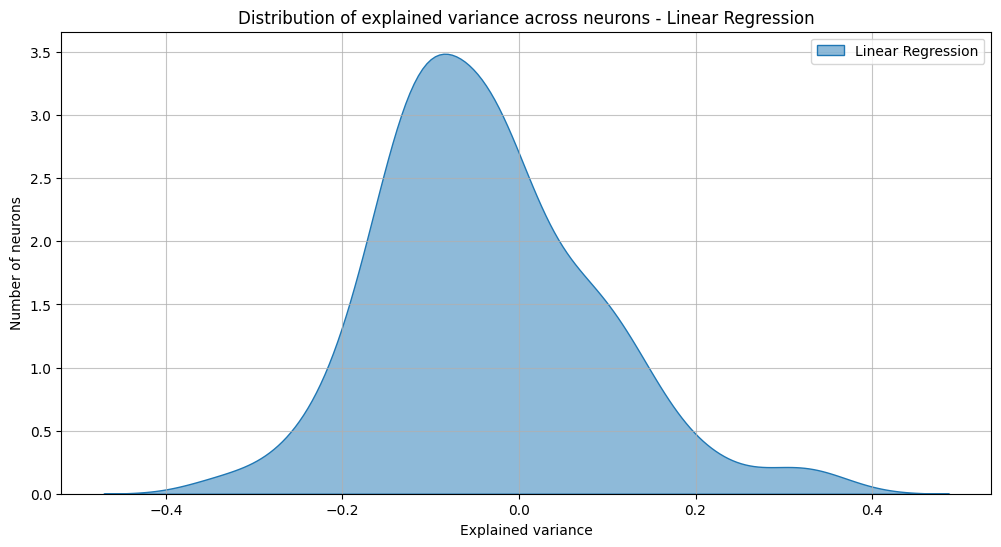

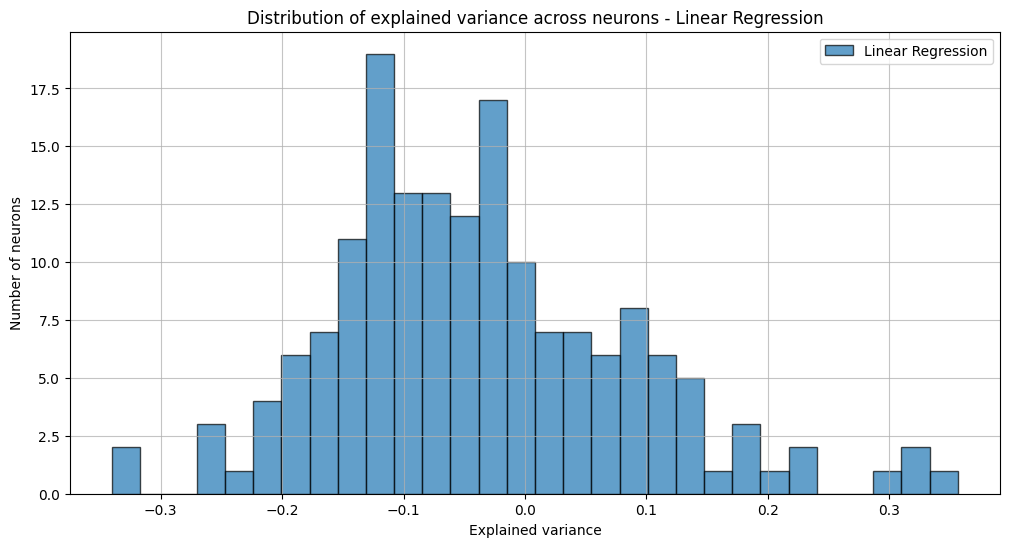

In [15]:
plot_ev_distributions([ev_linear], [model_linear], kde=True)
plot_ev_distributions([ev_linear], [model_linear], kde=False)

##### Ridge regression with $\alpha$=100

In [16]:
# Ridge regression with alpha = 100
ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)

Ridge(alpha=100)

In [17]:
# Results
corr_ridge, ev_ridge = evaluate_model(ridge, X_val, y_val)
mean_corr_ridge, mean_ev_ridge = np.mean(corr_ridge), np.mean(ev_ridge)
model_ridge = r"Ridge Regression ($\alpha=100$)"
print(model_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge))

Ridge Regression ($\alpha=100$)
Mean pearson correlation: 0.1707
Mean explained variance: -0.7898


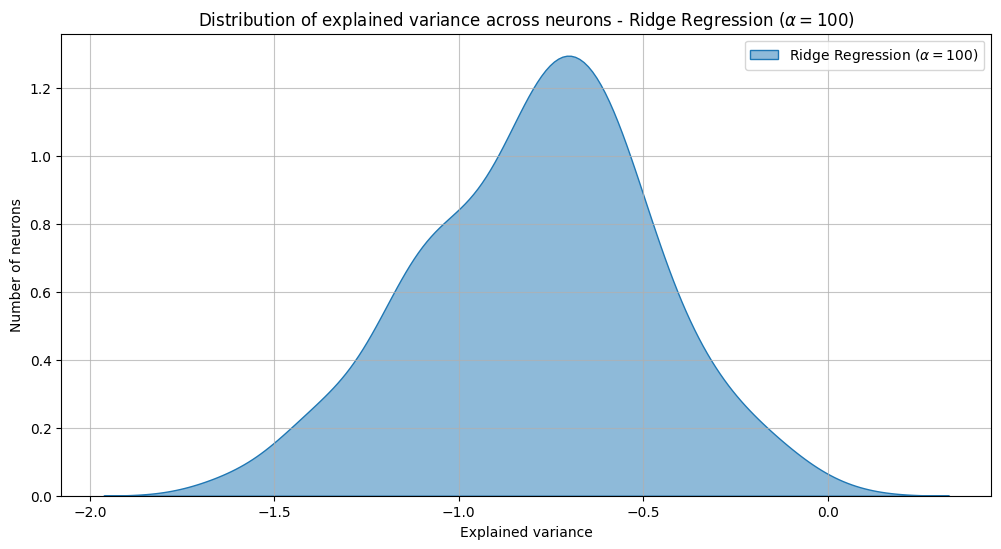

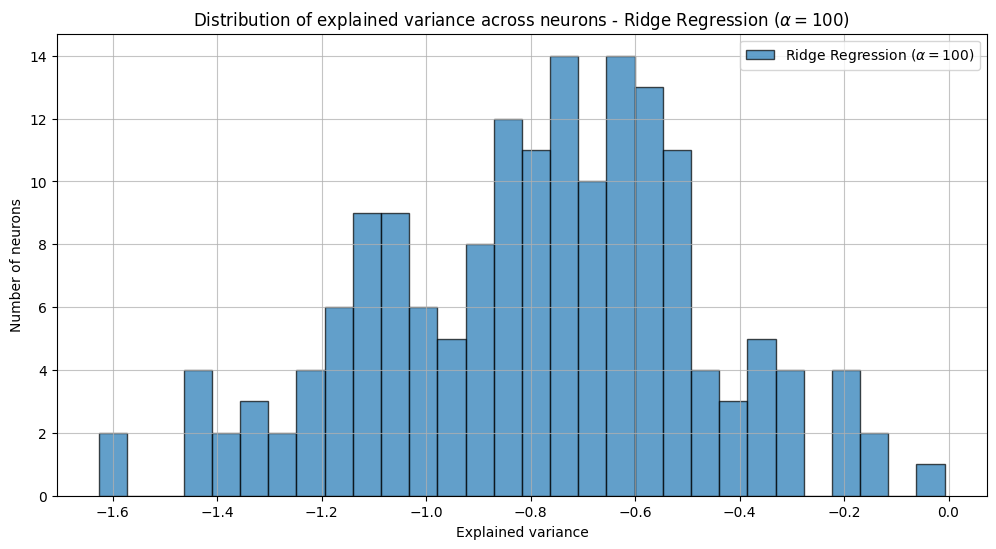

In [18]:
plot_ev_distributions([ev_ridge], [model_ridge], kde=True)
plot_ev_distributions([ev_ridge], [model_ridge], kde=False)

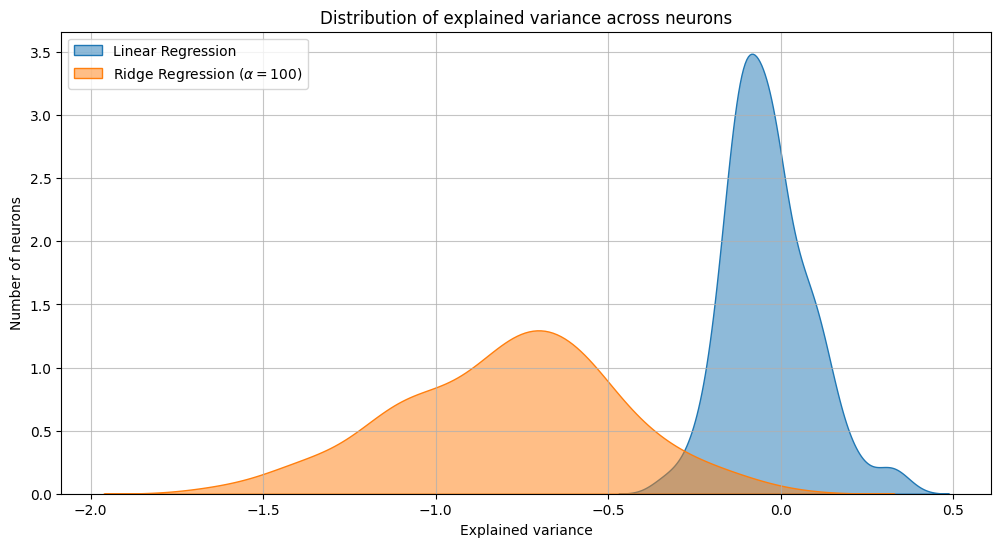

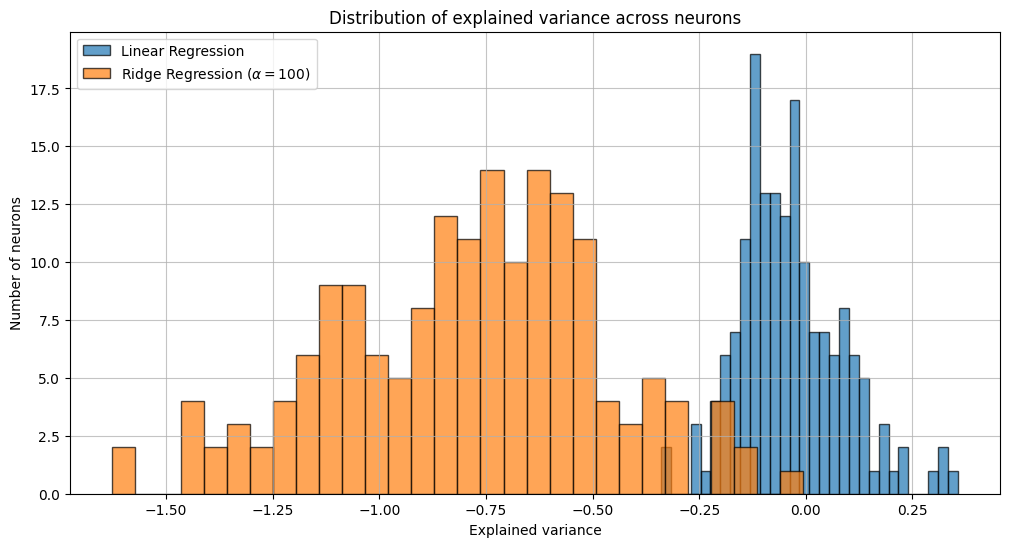

In [19]:
# Visual comparison of the Linear Regression and Ridge Regression models
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=True)
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=False)

### Retain 1000 PCs and predict neural activity based on them. 

In [20]:
# PCA
pca = PCA(n_components=1000)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)

##### Linear Regression with PCA

In [21]:
# Linear regression on PCA
linear_pca = LinearRegression()
linear_pca.fit(X_train_pca, y_train)

LinearRegression()

In [22]:
# Results
corr_linear_pca, ev_linear_pca = evaluate_model(linear_pca, X_val_pca, y_val)
mean_corr_linear_pca, mean_ev_linear_pca = np.mean(corr_linear_pca), np.mean(ev_linear_pca)
model_linear_pca = "Linear Regression on PCA"
print(model_linear_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_linear_pca))

Linear Regression on PCA
Mean pearson correlation: 0.2178
Mean explained variance: -0.0743


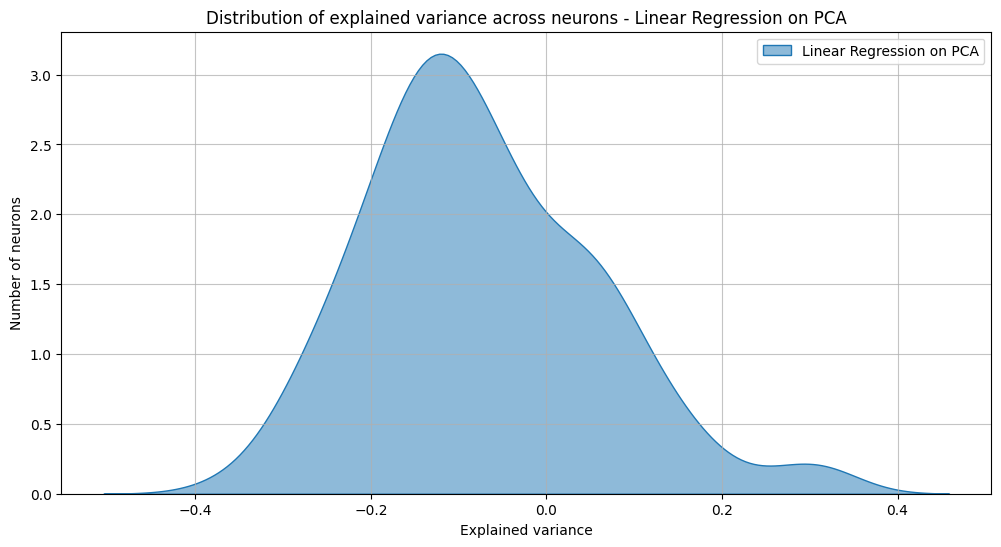

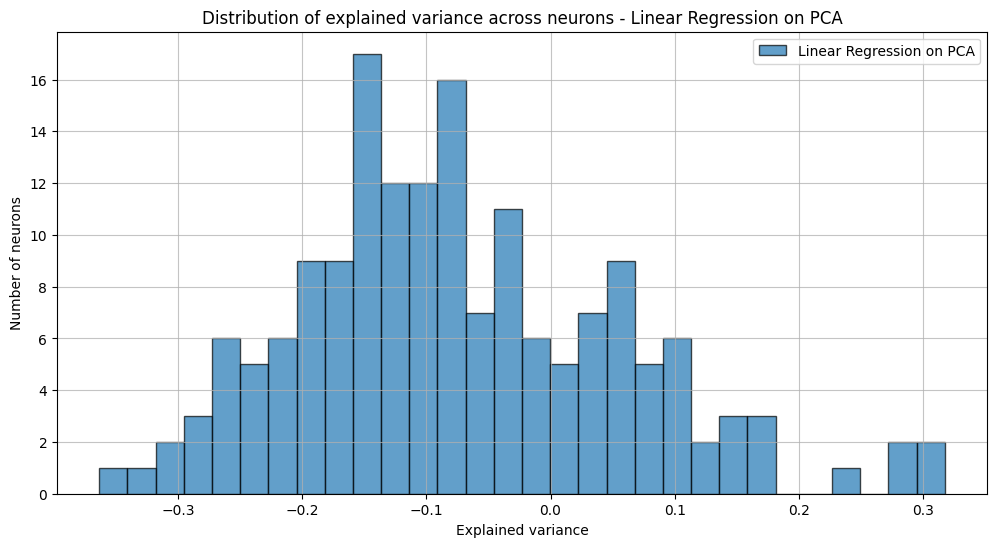

In [23]:
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=True)
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=False)

##### Ridge regression with $\alpha$=100 and PCA

In [24]:
# Ridge regression on PCA
ridge_pca = Ridge(alpha=100)
ridge_pca.fit(X_train_pca, y_train)

Ridge(alpha=100)

In [25]:
# Results
corr_ridge_pca, ev_ridge_pca = evaluate_model(ridge_pca, X_val_pca, y_val)
mean_corr_ridge_pca, mean_ev_ridge_pca = np.mean(corr_ridge_pca), np.mean(ev_ridge_pca)
model_ridge_pca = r"Ridge Regression on PCA ($\alpha=100$)"
print(model_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge_pca))

Ridge Regression on PCA ($\alpha=100$)
Mean pearson correlation: 0.2180
Mean explained variance: -0.0731


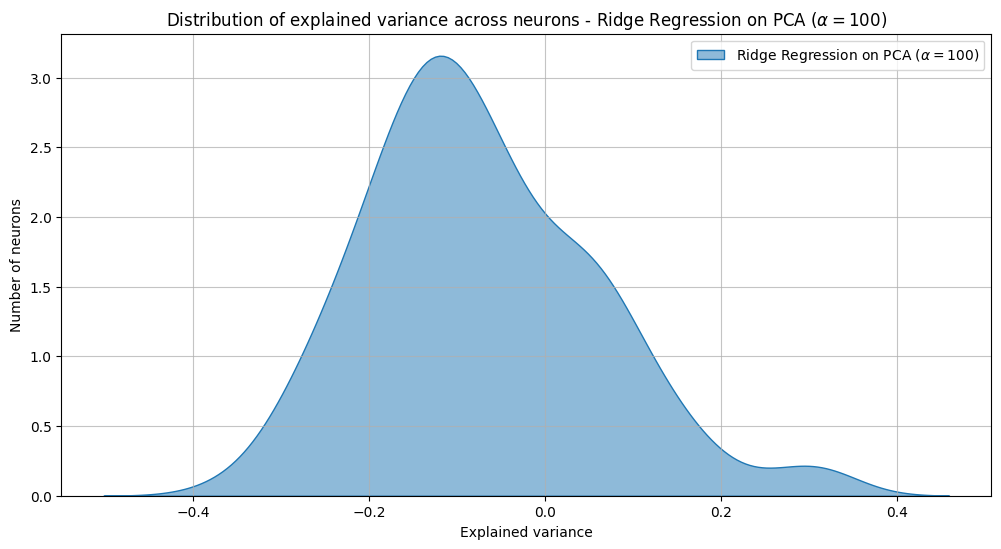

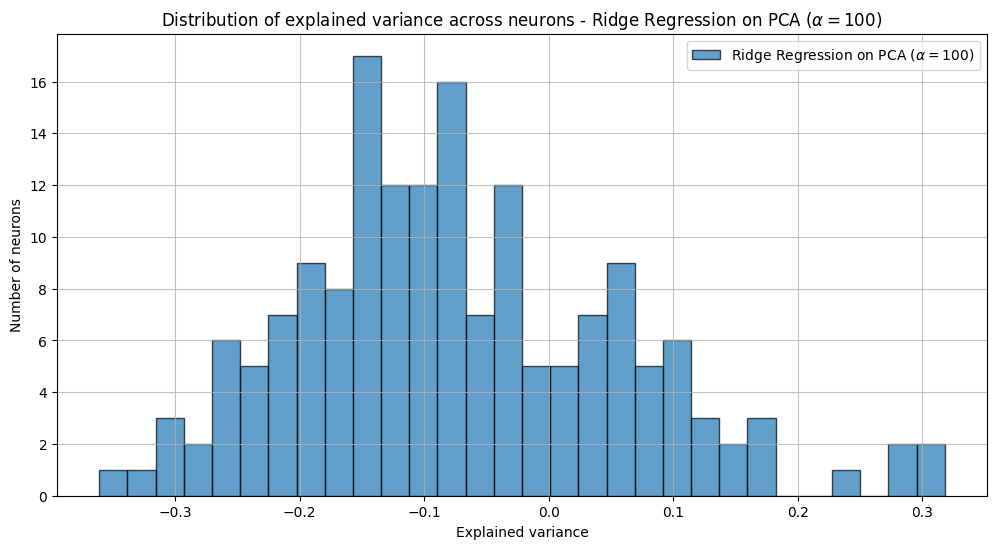

In [26]:
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=False)

##### Comparison of the models before and after PCA

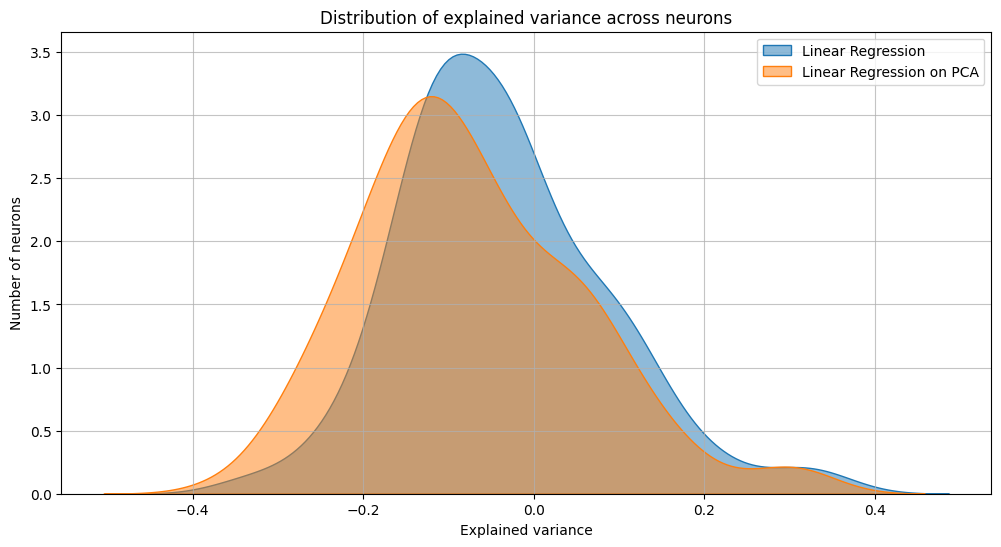

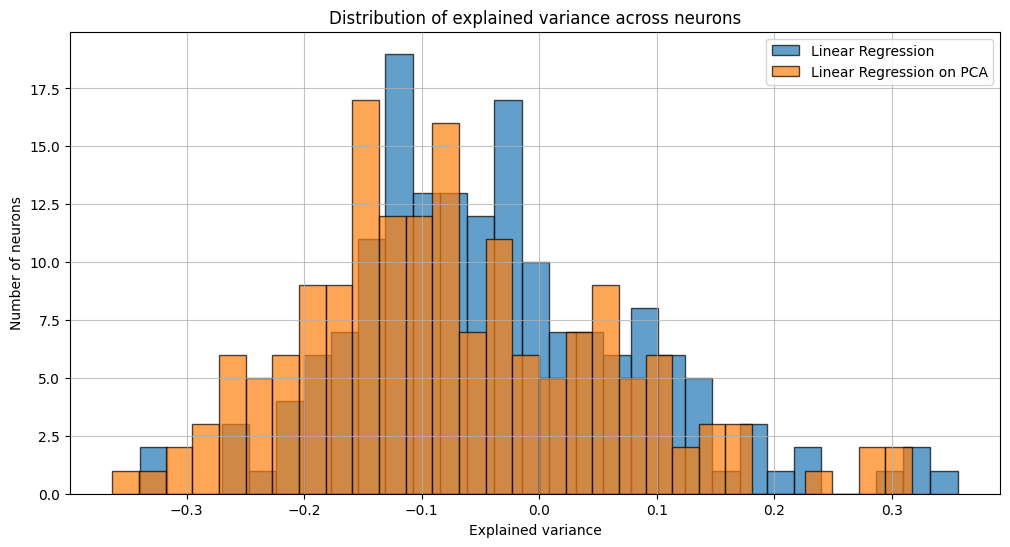

In [27]:
# Comparison linear before and after PCA
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=True)
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=False)

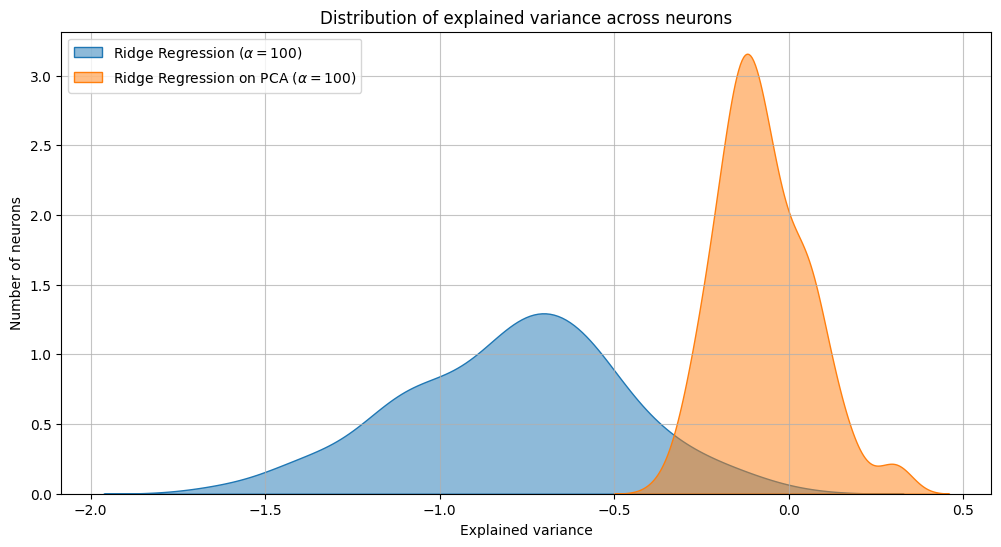

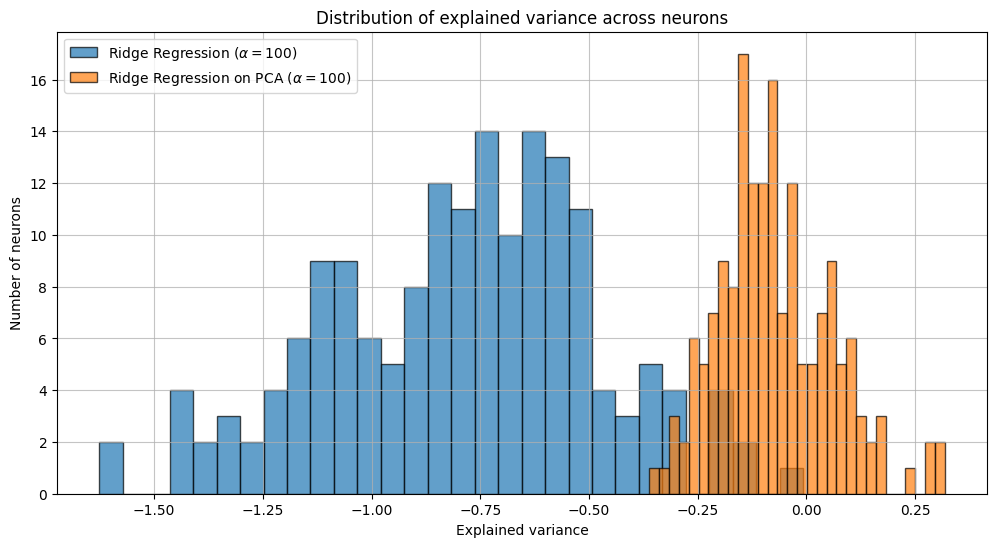

In [28]:
# Comparison of ridge before and after PCA
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=False)

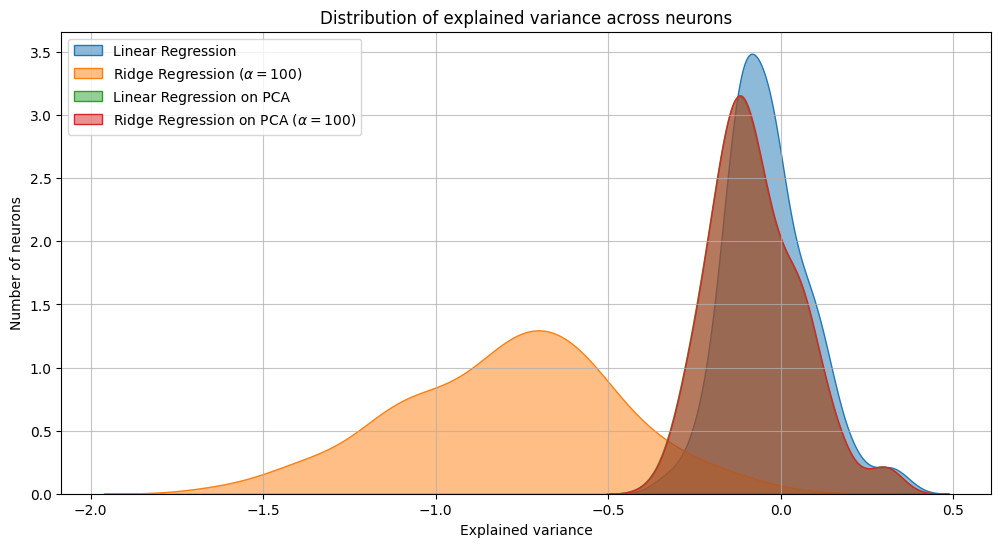

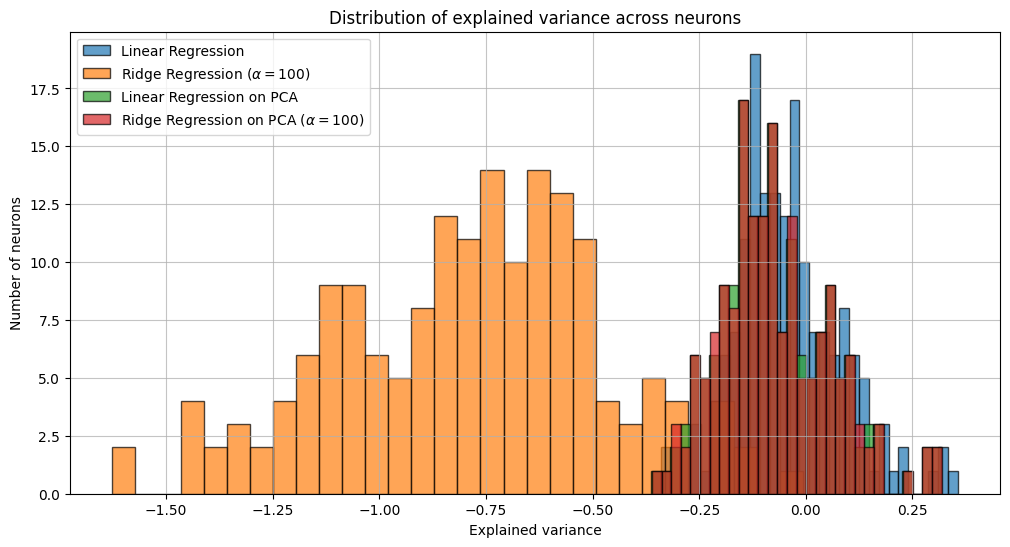

In [29]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=False)

#### Hyperparameter tuning with cross-fold validation on Ridge Regression.

##### Tuned ridge regression without pca

In [30]:
warnings.filterwarnings("ignore", message="Singular matrix in solving dual problem.*")
warnings.filterwarnings("ignore", message="Ill-conditioned matrix.*result may not be accurate")

In [31]:
# Define the range of alpha values
alphas = np.logspace(0, 8, 20)

# Perform Ridge regression with cross-validation
ridge_cv = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv.fit(X_train, y_train)

# Get the best alpha
best_alpha = ridge_cv.alpha_
print(f"Best alpha: {best_alpha}")

Best alpha: 297635.1441631313


In [32]:
# Results
corr_best_ridge, ev_best_ridge = evaluate_model(ridge_cv, X_val, y_val)
mean_corr_best_ridge, mean_ev_best_ridge = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge = r"Best Ridge Regression ($\alpha={:.2f}$)".format(best_alpha)
print(model_best_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge))

Best Ridge Regression ($\alpha=297635.14$)
Mean pearson correlation: 0.2863
Mean explained variance: 0.0933


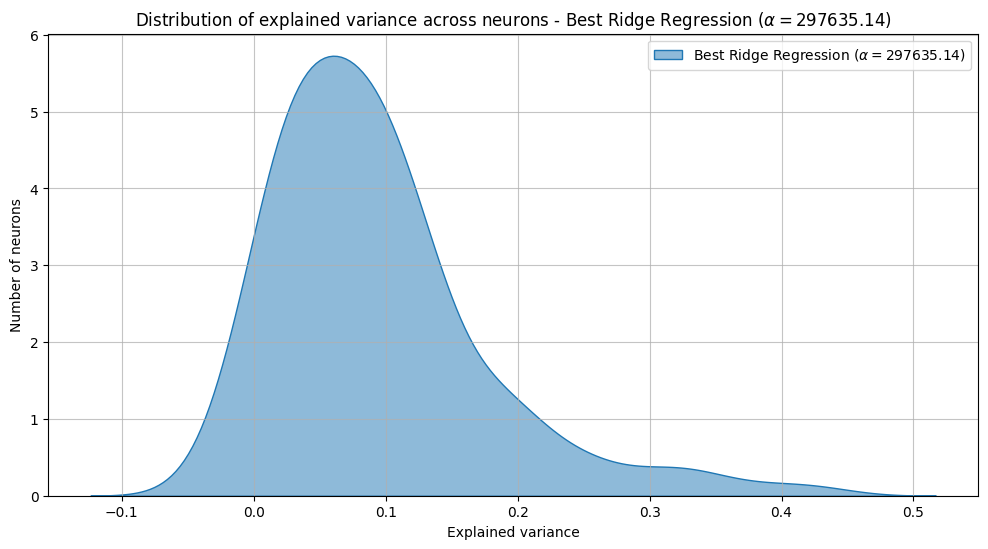

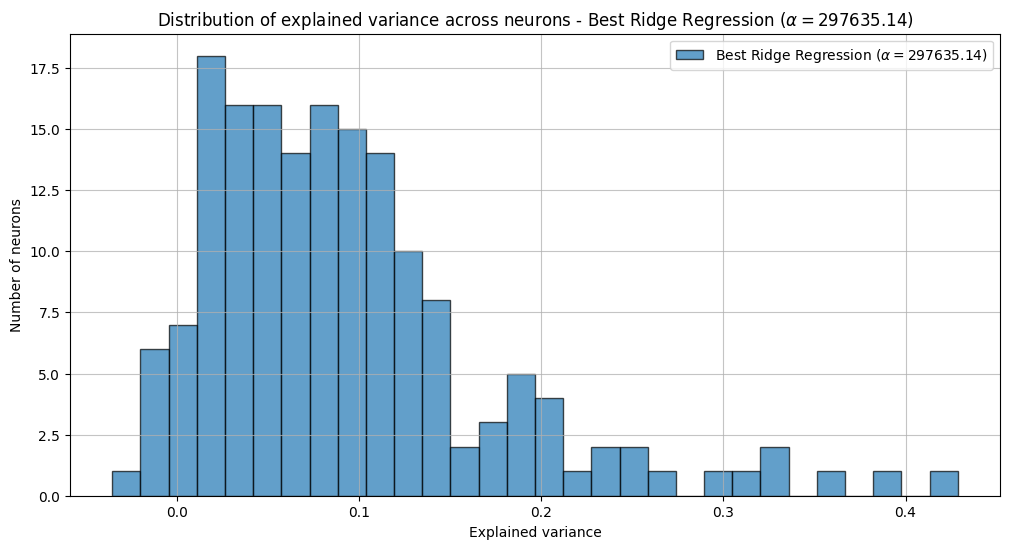

In [33]:
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=True)
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=False)

##### Tuned ridgeregression with pca

In [34]:
# Perform Ridge regression with cross-validation
ridge_cv_pca = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv_pca.fit(X_train_pca, y_train)

# Get the best alpha
best_alpha_pca = ridge_cv.alpha_
print(f"Best alpha: {best_alpha_pca}")

Best alpha: 297635.1441631313


In [35]:
# Evaluate the best model on the validation set
corr_best_ridge_pca, ev_best_ridge_pca = evaluate_model(ridge_cv_pca, X_val_pca, y_val)
mean_corr_best_ridge_pca, mean_ev_best_ridge_pca = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge_pca = r"Best Ridge Regression on PCA ($\alpha={:.2f}$)".format(best_alpha_pca)
print(model_best_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge_pca))

Best Ridge Regression on PCA ($\alpha=297635.14$)
Mean pearson correlation: 0.2863
Mean explained variance: 0.0933


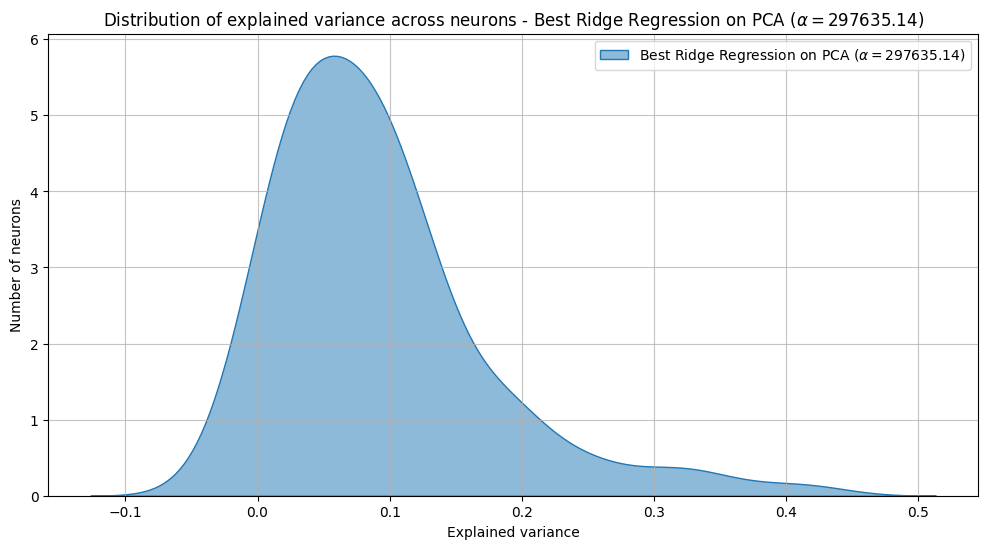

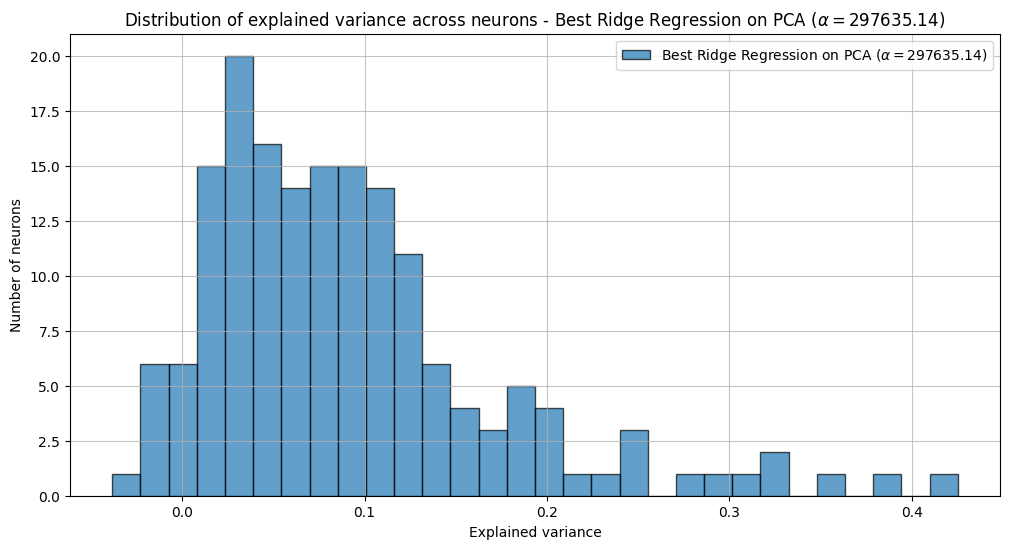

In [36]:
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=False)

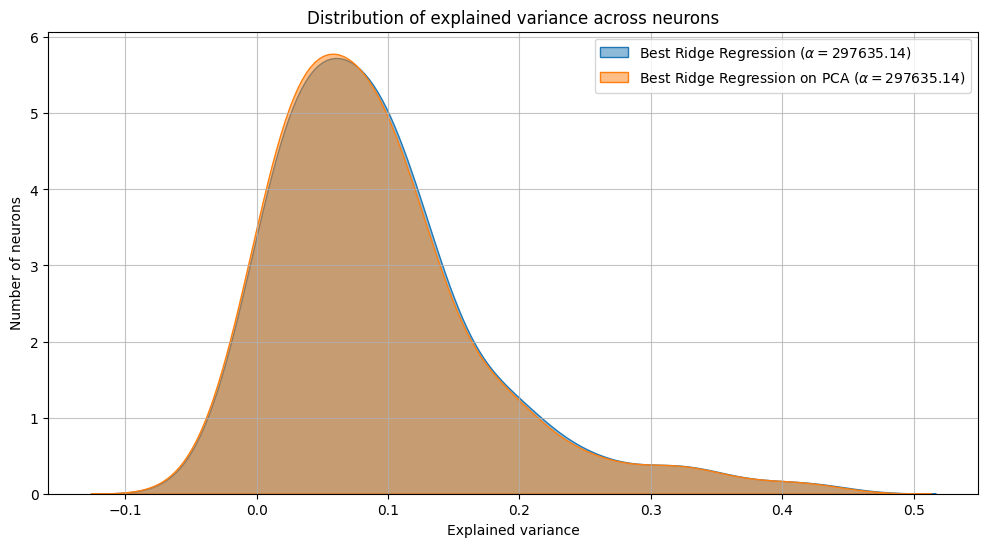

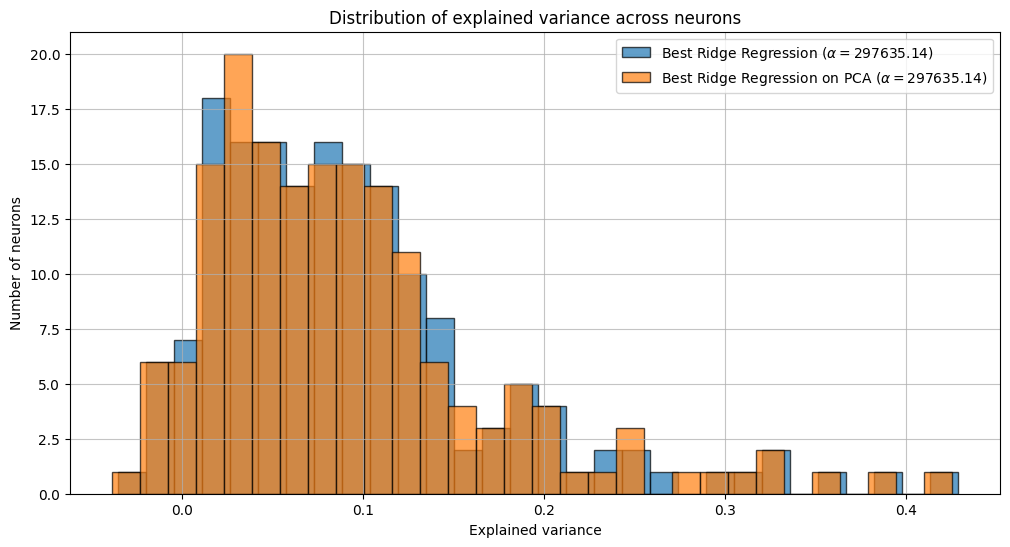

In [37]:
# Compare tuned ridge with PCA, and without PCA
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca], 
                      [model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca],
                      [model_best_ridge, model_best_ridge_pca], kde=False)

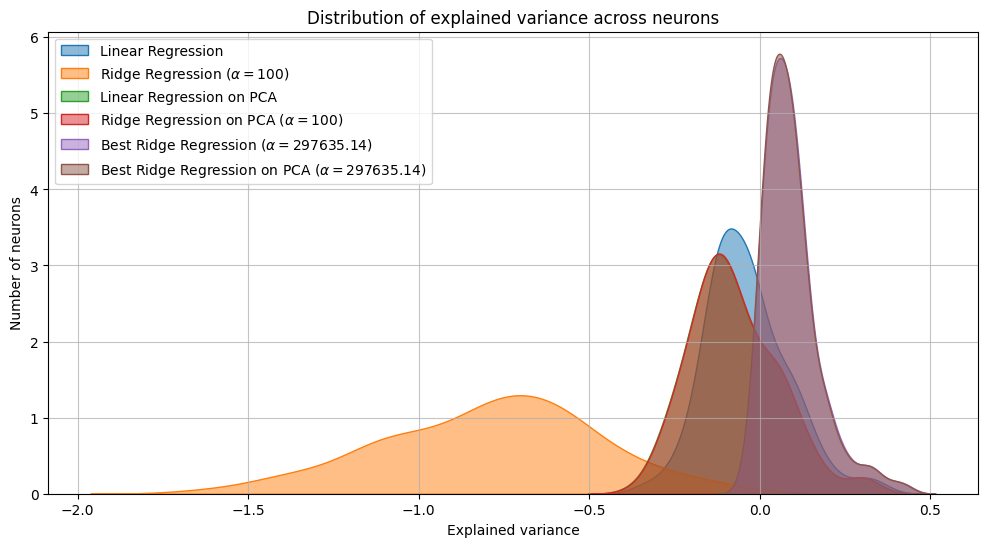

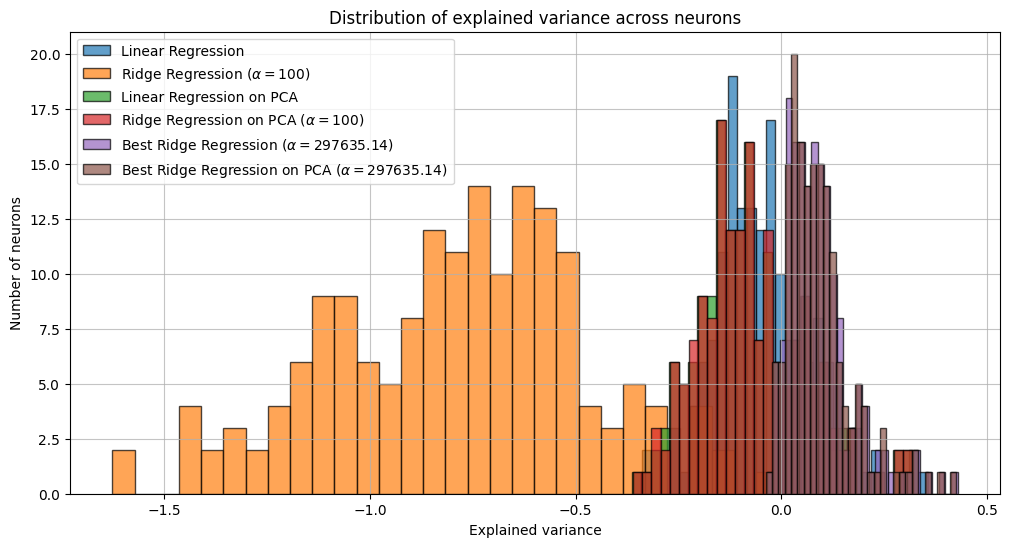

In [38]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=False)

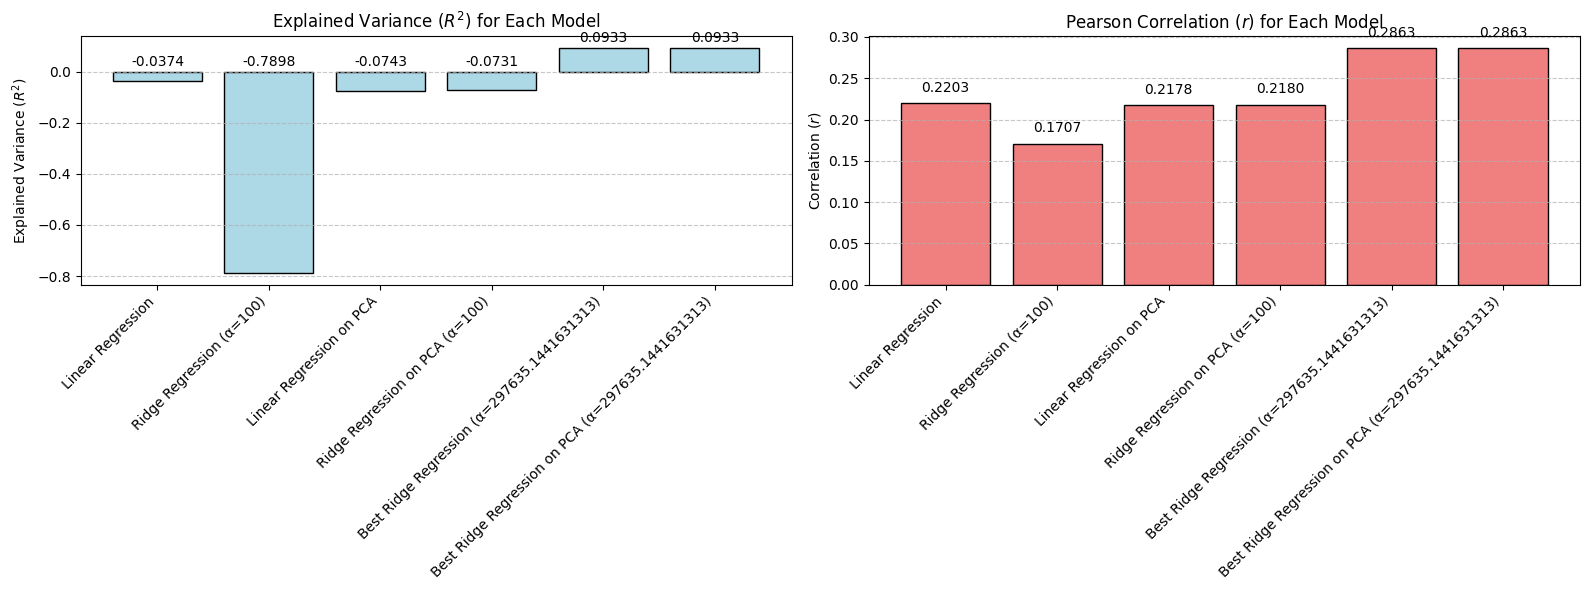

In [39]:
all_variances_total = [mean_ev_linear, mean_ev_ridge, mean_ev_linear_pca, mean_ev_ridge_pca, mean_ev_best_ridge, mean_ev_best_ridge_pca]
all_correlations_total = [mean_corr_linear, mean_corr_ridge, mean_corr_linear_pca, mean_corr_ridge_pca, mean_corr_best_ridge, mean_corr_best_ridge_pca]
model_names_total = ['Linear Regression', 'Ridge Regression (α=100)', 'Linear Regression on PCA',
               'Ridge Regression on PCA (α=100)', f"Best Ridge Regression (α={best_alpha_pca})", f"Best Ridge Regression on PCA (α={best_alpha_pca})"]

def plot_comparison(model_names, all_variances, all_correlations):
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Explained Variance bar plot
    axs[0].bar(model_names, all_variances, color='lightblue', edgecolor='black')
    for i, ev in enumerate(all_variances):
        axs[0].text(i, max(0, ev) + 0.01, f"{ev:.4f}", ha='center', va='bottom', fontsize=10)
    axs[0].set_title("Explained Variance ($R^2$) for Each Model")
    axs[0].set_ylabel("Explained Variance ($R^2$)")
    axs[0].set_xticks(range(len(model_names)))
    axs[0].set_xticklabels(model_names, rotation=45, ha='right')
    axs[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Pearson Correlation bar plot
    axs[1].bar(model_names, all_correlations, color='lightcoral', edgecolor='black')
    for i, corr in enumerate(all_correlations):
        axs[1].text(i, corr + 0.01, f"{corr:.4f}", ha='center', va='bottom', fontsize=10)
    axs[1].set_title("Pearson Correlation ($r$) for Each Model")
    axs[1].set_ylabel("Correlation ($r$)")
    axs[1].set_xticks(range(len(model_names)))
    axs[1].set_xticklabels(model_names, rotation=45, ha='right')
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    
plot_comparison(model_names_total, all_variances_total, all_correlations_total)


## Part 2: Predict the neural activity with the task-driven modeling approach ResNet50

We extract the corresponding activations of the following layers ['conv1','layer1','layer2','layer3','layer4','avgpool'] and compute the 1000 PCs for each layer activation. These are then used to predict neural activity. The pretrained model performs better than the randomly initialized model.

In [ ]:

def extract_layer_outputs(model, data_loader, layers):
    """
    Extracts raw activations from specified layers for all samples in data_loader.

    Args:
        model (torch.nn.Module): PyTorch model with registered layers.
        data_loader (DataLoader): DataLoader providing input batches.
        layers (list of str): Layer names to hook and extract activations.

    Returns:
        dict: Mapping from layer name to concatenated numpy array of activations.
    """
    activations = {name: [] for name in layers}

    # Register hooks for each layer to capture outputs
    hooks = []
    for name in layers:
        layer = getattr(model, name)
        hook = layer.register_forward_hook(
            lambda module, inp, out, layer_name=name: activations[layer_name].append(out.detach().cpu().numpy())
        )
        hooks.append(hook)

    # Run forward passes without gradient tracking
    model.eval()
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Extracting activations"):
            # Prepare input tensor
            x = torch.from_numpy(np.stack(batch).astype(np.float32))
            _ = model(x)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Concatenate collected outputs per layer
    return {name: np.concatenate(activations[name], axis=0) for name in layers}

In [ ]:
def compute_pca(train_acts, val_acts, num_components):
    """
    Fits PCA on training activations and transforms both train and validation data.

    Args:
        train_acts (np.ndarray): Activations for training data of shape (N, ...).
        val_acts (np.ndarray): Activations for validation data of shape (M, ...).
        num_components (int): Number of PCA components to keep.

    Returns:
        tuple: (train_pca, val_pca) transformed arrays.
    """
    # Reshape to 2D: (n_samples, features)
    n_train = train_acts.shape[0]
    train_flat = train_acts.reshape(n_train, -1)

    n_val = val_acts.shape[0]
    val_flat = val_acts.reshape(n_val, -1)

    pca = PCA(n_components=num_components)
    pca.fit(train_flat)

    train_pca = pca.transform(train_flat)
    val_pca = pca.transform(val_flat)

    return train_pca, val_pca

In [ ]:
def save_dict(data_dict, filepath):
    """
    Saves a Python object to a pickle file.

    Args:
        data_dict (any): Object to pickle.
        filepath (str): Path to save the pickle file.
    """
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

Computing or loading PCA reduced activations from pretrained ResNet50. The first time you run the next cell, put run_model to True. This will take a long time but will compute all the PC. If this has already been done once, you can set it to False and use the already computed files. Do not forget to adapt the paths.

In [43]:
# Toggle whether to rerun model inference or load precomputed features
run_model = False

# PCA parameters
layers = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
num_components = 1000
batch_size = 64

# Adapt here the paths
train_path_pca = './Documents/NX/NX-414-Project/data/pca_dict_train.pkl'
val_path_pca = './Documents/NX/NX-414-Project/data/pca_dict_val.pkl'

if run_model:
    # Load pretrained ResNet50
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)

    # Prepare data loaders (replace with actual dataset variables)
    train_loader = DataLoader(stimulus_train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(stimulus_val, batch_size=batch_size, shuffle=False)

    # Extract raw activations
    train_acts = extract_layer_outputs(model, train_loader, layers)
    val_acts = extract_layer_outputs(model, val_loader, layers)

    # Compute PCA for each layer and collect results
    pca_train = {}
    pca_val = {}
    for layer in tqdm(layers):
        pca_train[layer], pca_val[layer] = compute_pca(
            train_acts[layer], val_acts[layer], num_components
        )

    # Save PCA-transformed activations
    save_dict(pca_train, train_path_pca)
    save_dict(pca_val, val_path_pca)
else:
    # Load precomputed PCA features
    pca_train = pickle.load(open(train_path_pca, 'rb'))
    pca_val = pickle.load(open(val_path_pca, 'rb'))

In [ ]:
def compute_corr(y_true, y_pred, divide=False):
    """
    Compute Pearson correlation coefficient(s) between y_true and y_pred.

    Parameters
    ----------
    y_true : array-like, shape (n_samples, n_neurons)
        Ground-truth values.
    y_pred : array-like, shape (n_samples, n_neurons)
        Predicted values.
    divide : bool, default=False
        If True, return per-neuron correlations (one per column).
        If False, return a single correlation over all entries.

    Returns
    -------
    float or np.ndarray
        Correlation coefficient (scalar) if divide=False, or
        1-D array of length n_neurons if divide=True.
    """

    
    if divide:
        # Compute Pearson r for each column separately
        corrs = []
        for i in range(y_true.shape[1]):
            # np.corrcoef returns the 2×2 correlation matrix
            r = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
            corrs.append(r)
        return np.array(corrs)
    else:
        # Flatten and compute overall correlation
        return np.corrcoef(y_true.ravel(), y_pred.ravel())[0, 1]

Evaluation of how well the different ResNet50 layers predict neural activity using RidgeCV on PCA reduced activations

In [ ]:
alphas = np.logspace(0, 8, 20) 

In [ ]:
def ridgecv_eval(X_tr, y_tr, X_val, y_val):
    # instantiate RidgeCV with explained_variance scoring
    model = RidgeCV(
        alphas=alphas,
        scoring='explained_variance',  # maximize EV
        cv=5,
        store_cv_results=False,         # set True if you want CV predictions
        fit_intercept=True
    )
    model.fit(X_tr, y_tr)
    
    # best α
    best_alpha = model.alpha_
    
    # predict & score
    y_pred = model.predict(X_val)
    ev   = explained_variance_score(y_val, y_pred)
    corr = compute_corr(y_val, y_pred)
    return best_alpha, ev, corr

In [47]:
# Initialize lists to store results
ev_layer = []
corr_layer = []

for name in tqdm(layers):
    
    # prepare the data
    X_train = pca_train[name]
    X_val = pca_val[name]
    y_train = spikes_train
    y_val = spikes_val
    
    best_alpha, ev, corr = ridgecv_eval(X_train, y_train, X_val, y_val)
    ev_layer.append(ev)
    corr_layer.append(corr)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:34<00:00,  5.82s/it]


In [ ]:
def plot_bar_with_labels(x, y, title, ylabel, color):
    """
    Creates a bar plot of y over x, annotates each bar with its height.
    """
    plt.figure(figsize=(12, 6))
    bars = plt.bar(x, y, color=color, edgecolor='black')
    plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
    plt.title(title)
    plt.ylim(-0.1, 1)
    plt.xlabel('Layer')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # Annotate each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.03,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

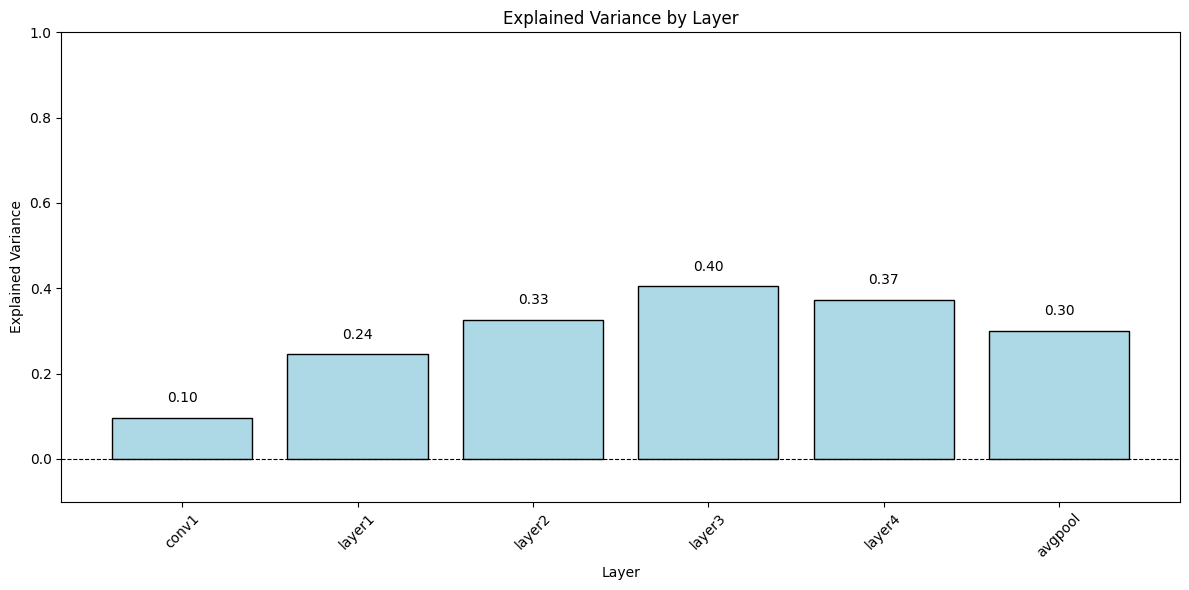

In [49]:
# Plot 1: Explained Variance
plot_bar_with_labels(
    layers,
    ev_layer,
    title='Explained Variance by Layer',
    ylabel='Explained Variance',
    color='lightblue'
)

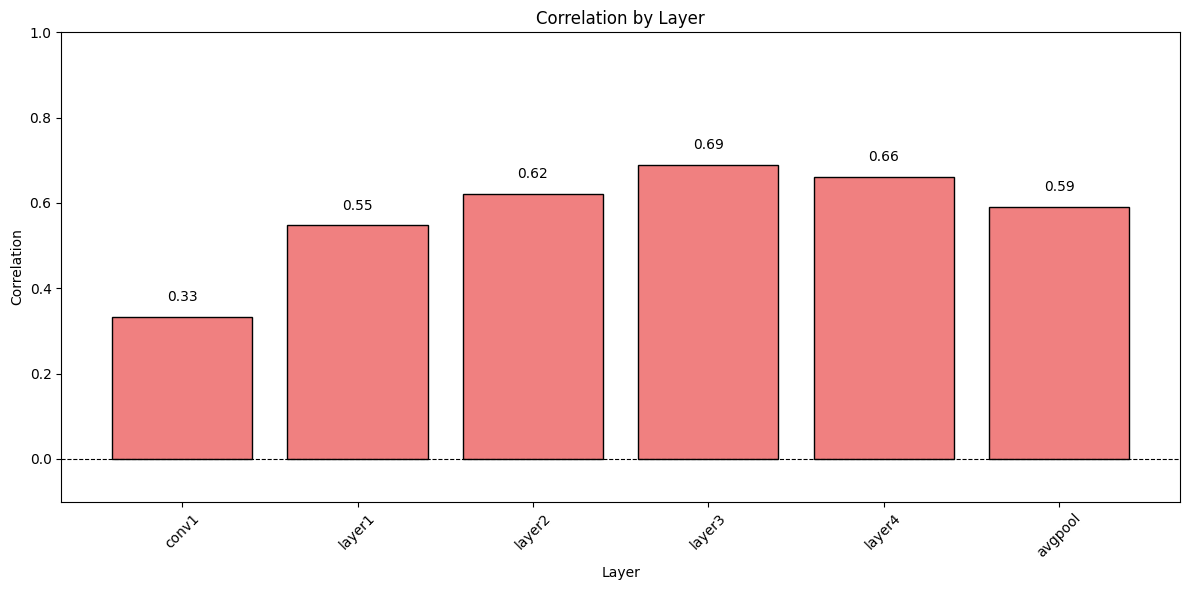

In [50]:
# Plot 2: Correlation
plot_bar_with_labels(
    layers,
    corr_layer,
    title='Correlation by Layer',
    ylabel='Correlation',
    color='lightcoral'
)

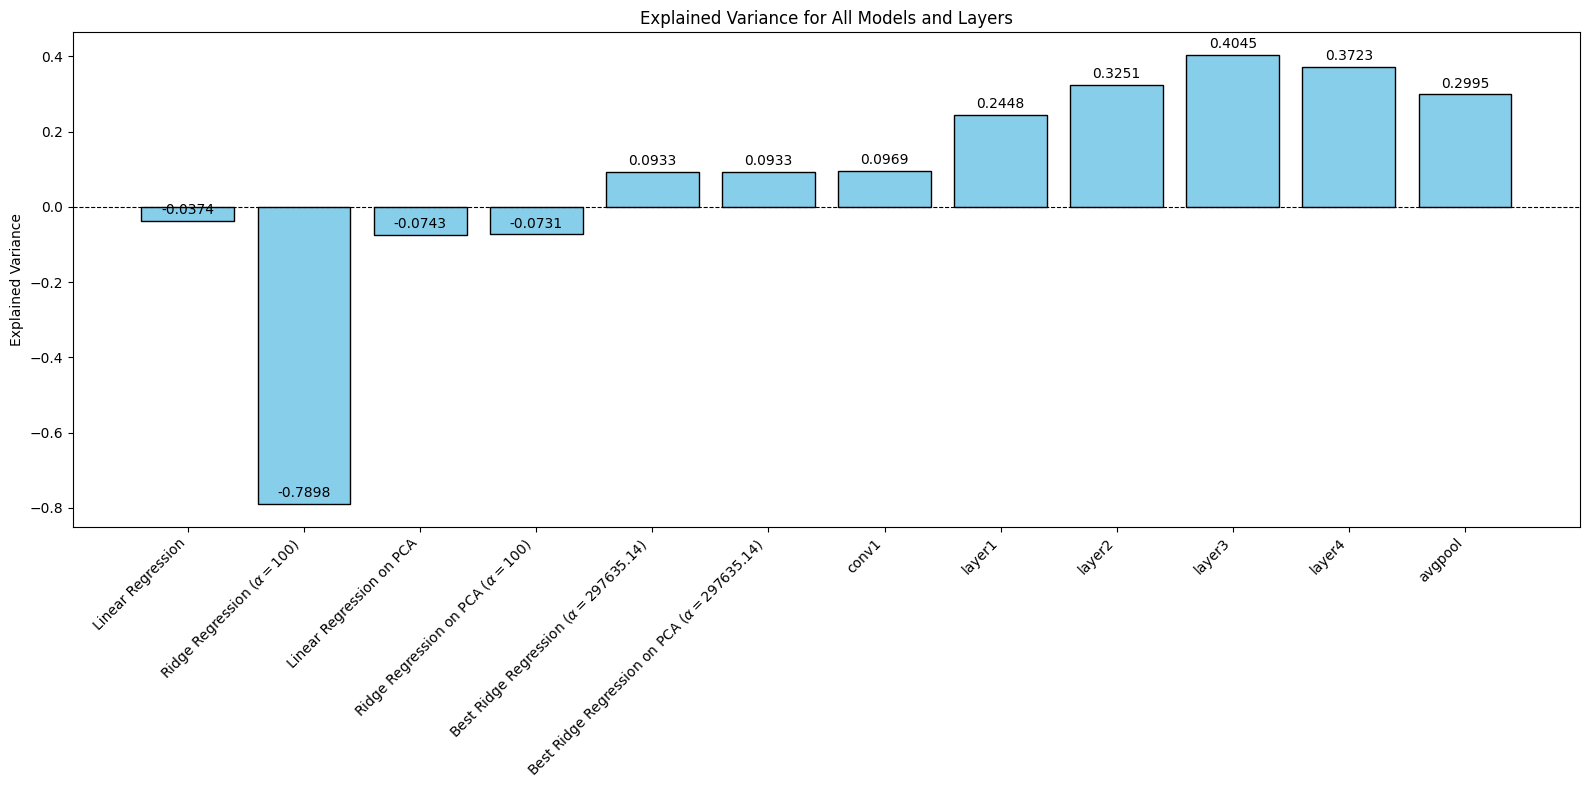

In [51]:
# Define the models and their corresponding metrics for week 6
models_week6 = [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca]
explained_variances = [mean_ev_linear, mean_ev_ridge, mean_ev_linear_pca, mean_ev_ridge_pca, mean_ev_best_ridge, mean_ev_best_ridge_pca]
correlations = [mean_corr_linear, mean_corr_ridge, mean_corr_linear_pca, mean_corr_ridge_pca, mean_corr_best_ridge, mean_corr_best_ridge_pca]

# Combine explained variance from Part 1 models and each layer
all_models = models_week6 + layers
all_explained_variances = explained_variances + ev_layer

# Plot the bar chart
plt.figure(figsize=(16, 8))
bars = plt.bar(all_models, all_explained_variances, color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
plt.title("Explained Variance for All Models and Layers")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

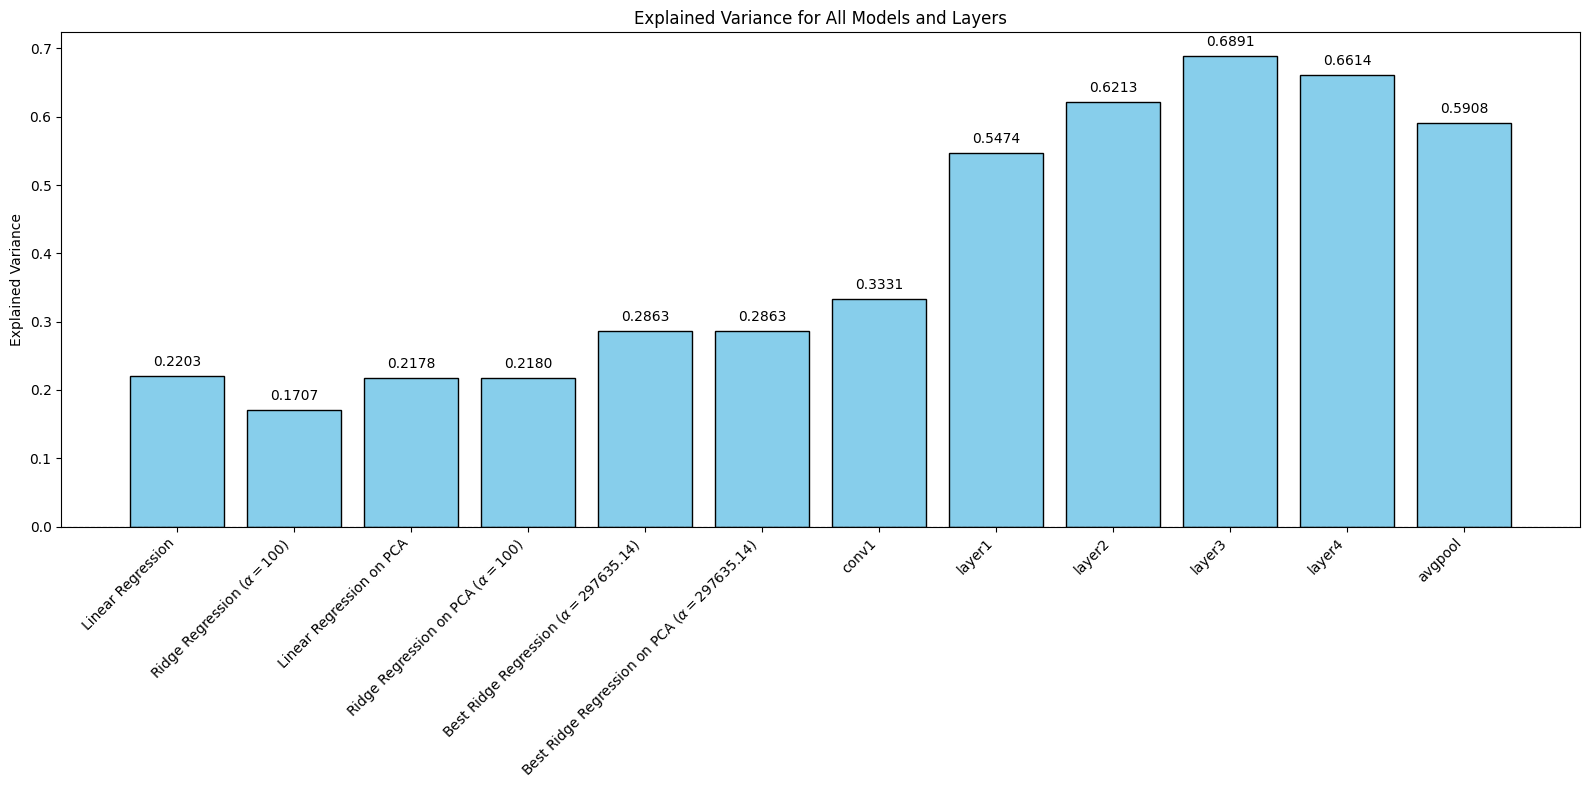

In [52]:
# Combine correlation from Part 1 models and each layer
all_models = models_week6 + layers
all_correlations = correlations + corr_layer

# Plot the bar chart
plt.figure(figsize=(16, 8))
bars = plt.bar(all_models, all_correlations, color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
plt.title("Explained Variance for All Models and Layers")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Computing or Loading PCA features from randomly initialized ResNet50

In [53]:
# Toggle whether to rerun model inference or load precomputed features
run_model = False

# PCA parameters
layers = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
num_components = 1000
batch_size = 64

random_train_path = './Documents/NX/NX-414-Project/data/pca_dict_train_random.pkl'
random_val_path = './Documents/NX/NX-414-Project/data/pca_dict_val_random.pkl'

if run_model:
    # Load pretrained ResNet50
    model = resnet50(weights=None)

    # Prepare data loaders (replace with actual dataset variables)
    train_loader = DataLoader(stimulus_train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(stimulus_val, batch_size=batch_size, shuffle=False)

    # Extract raw activations
    train_acts = extract_layer_outputs(model, train_loader, layers)
    val_acts = extract_layer_outputs(model, val_loader, layers)

    # Compute PCA for each layer and collect results
    pca_train_random = {}
    pca_val_random = {}
    for layer in tqdm(layers):
        pca_train_random[layer], pca_val_random[layer] = compute_pca(
            train_acts[layer], val_acts[layer], num_components
        )
        
    # Save PCA-transformed activations
    save_dict(pca_train_random, random_train_path)
    save_dict(pca_val_random, random_val_path)
else:
    # Load precomputed PCA features
    pca_train_random = pickle.load(open(random_train_path, 'rb'))
    pca_val_random = pickle.load(open(random_val_path, 'rb'))

Evaluation of how well the different ResNet50 layers predict neural activity using RidgeCV on PCA reduced activations

In [54]:
# Initialize lists to store results
ev_layer = []
corr_layer = []

for name in tqdm(layers):
    
    # prepare the data
    X_train = pca_train_random[name]
    X_val = pca_val_random[name]
    y_train = spikes_train
    y_val = spikes_val
    
    best_alpha, ev, corr = ridgecv_eval(X_train, y_train, X_val, y_val)
    ev_layer.append(ev)
    corr_layer.append(corr)


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:32<00:00,  5.48s/it]


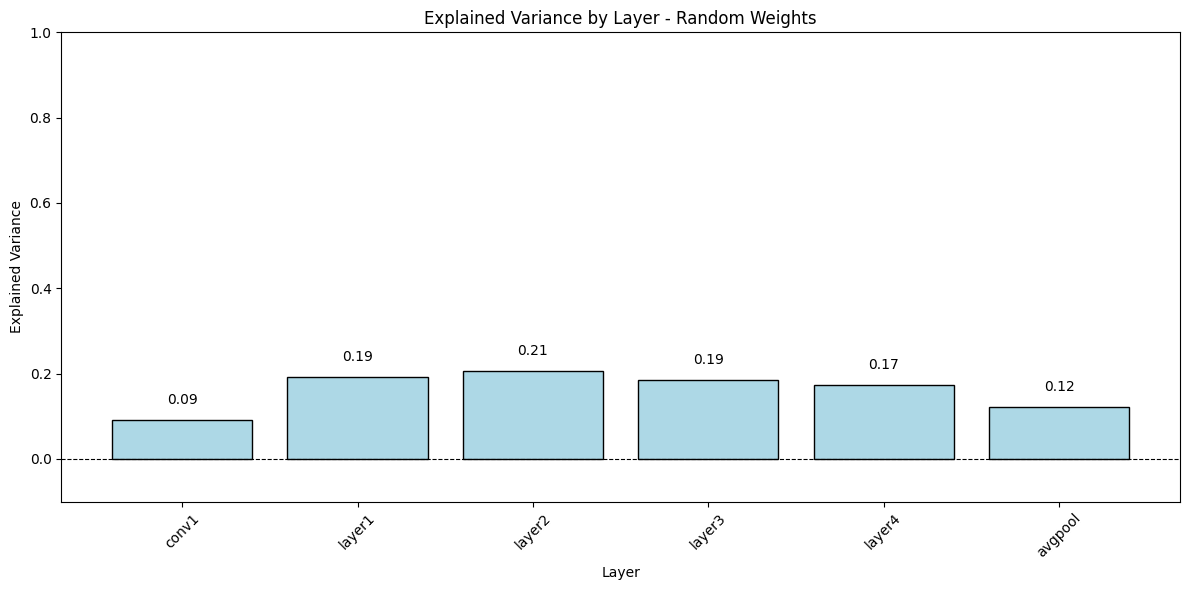

In [55]:
# Plot 1: Explained Variance
plot_bar_with_labels(
    layers,
    ev_layer,
    title='Explained Variance by Layer - Random Weights',
    ylabel='Explained Variance',
    color='lightblue'
)

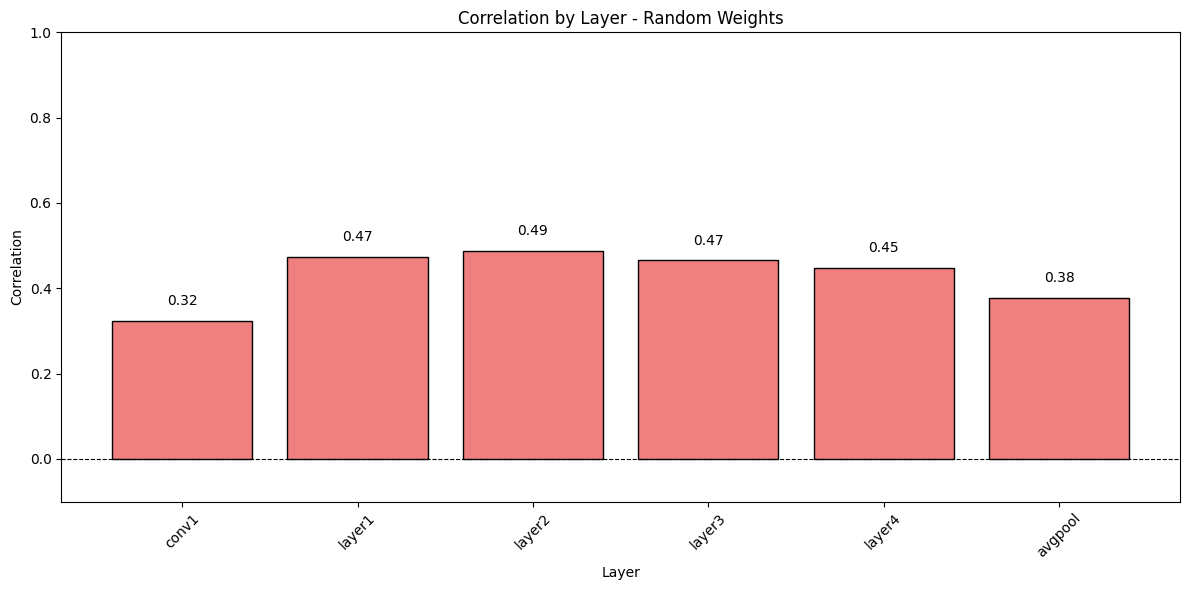

In [56]:
# Plot 2: Correlation
plot_bar_with_labels(
    layers,
    corr_layer,
    title='Correlation by Layer - Random Weights',
    ylabel='Correlation',
    color='lightcoral'
)

Comparison of pretrained vs randomly initialized ResNet50 (layer3)

In [57]:
name = 'layer3'

X_train = pca_train[name]
X_train_random = pca_train_random[name]

X_val = pca_val[name]
X_val_random = pca_val_random[name]

y_train = spikes_train
y_val = spikes_val


# In the case we use the exact same alpha as in part 1
ridge = Ridge(alpha=297635.1441631313, fit_intercept=True)
ridge.fit(X_train, y_train)
y_val_pred = ridge.predict(X_val)
ev = explained_variance_score(y_val, y_val_pred)
corr = compute_corr(y_val, y_val_pred)

ridge_random = Ridge(alpha=297635.1441631313, fit_intercept=True)
ridge_random.fit(X_train_random, y_train)
y_val_pred_random = ridge.predict(X_val_random)
ev_random = explained_variance_score(y_val, y_val_pred_random)
corr_random = compute_corr(y_val, y_val_pred_random)


print('Explained variance for imagenetik weights is:', ev)
print('Explained variance for random weights is:', ev_random)

print('Correlation for imagenetik weights is:', corr)
print('Correlation for random weights is:', corr_random)

Explained variance for imagenetik weights is: 0.3696386218070984
Explained variance for random weights is: -9.567715644836426
Correlation for imagenetik weights is: 0.6710897849807073
Correlation for random weights is: -0.041823939963720975


In [58]:
# Fit & evaluate both (tuned ridge)

alpha_real, ev_real, corr_real = ridgecv_eval(X_train, y_train, X_val, y_val)
alpha_rand, ev_rand, corr_rand = ridgecv_eval(X_train_random, y_train, X_val_random, y_val)

print(rf"Imagenetik  → best $\alpha$  = {alpha_real:.3f}  |  ev = {ev_real:.4f}  |  corr = {corr_real:.4f}")
print(rf"Random      → best $\alpha$ = {alpha_rand:.3f}  |  ev = {ev_rand:.4f}  |  corr = {corr_rand:.4f}")

Imagenetik  → best $\alpha$  = 112883.789  |  ev = 0.4045  |  corr = 0.6891
Random      → best $\alpha$ = 784759.970  |  ev = 0.1851  |  corr = 0.4656


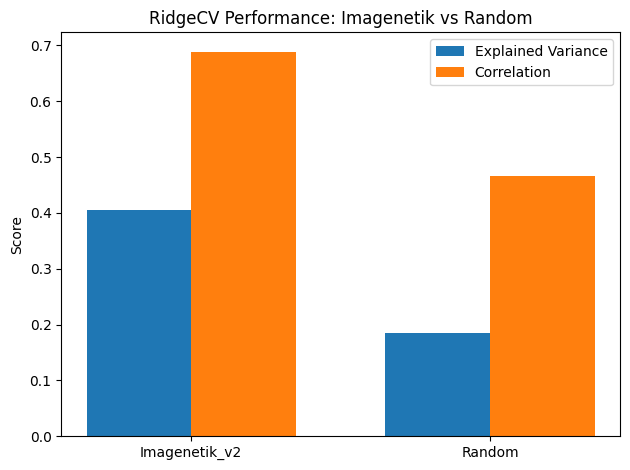

In [59]:
# Plot comparison
labels      = ['Imagenetik_v2', 'Random']
ev_scores   = [ev_real,   ev_rand]
corr_scores = [corr_real, corr_rand]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, ev_scores,   width, label='Explained Variance')
ax.bar(x + width/2, corr_scores, width, label='Correlation')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('RidgeCV Performance: Imagenetik vs Random')
ax.legend()
plt.tight_layout()
plt.show()

We compare these results, namely the pretrained and random initialized one, with all the models.

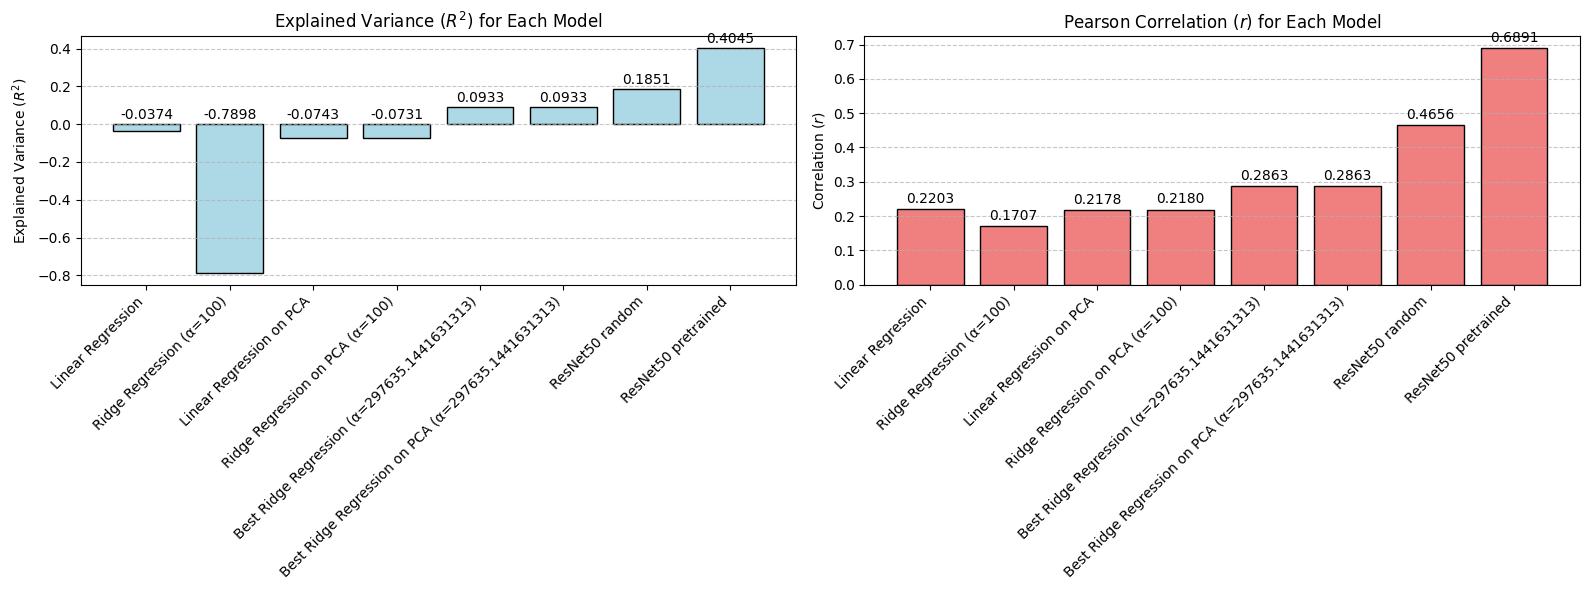

In [60]:
model_names_total.append('ResNet50 random')
all_variances_total.append(ev_rand)
all_correlations_total.append(corr_rand)

model_names_total.append('ResNet50 pretrained')
all_variances_total.append(ev_real)
all_correlations_total.append(corr_real)
plot_comparison(model_names_total, all_variances_total, all_correlations_total)

# Week 7: Predict the neural activity using a data-driven approach

First, we create the dataloader and load the train set and the validation set.

In [61]:
class ITDataset(Dataset):
    def __init__(self, stimuli, responses):
        self.stimuli = torch.tensor(stimuli, dtype=torch.float32)
        self.responses = torch.tensor(responses, dtype=torch.float32) 

    def __len__(self):
        return len(self.stimuli)

    def __getitem__(self, idx):
        return self.stimuli[idx], self.responses[idx]

# Create train and validation datasets
train_dataset = ITDataset(stimulus_train, spikes_train)
val_dataset = ITDataset(stimulus_val, spikes_val)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=60, shuffle=False)

We then define the Shallow CNN model with 3 convolutional layers followed by a relu activation function and one linear output layer.

In [62]:
class ShallowCNN(nn.Module):
    def __init__(self, num_neurons):
        super(ShallowCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc1 = nn.Linear(64 * 8 * 8, num_neurons)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        return x

num_neurons = spikes_train.shape[1]
model = ShallowCNN(num_neurons)

The loss function, learning rate and the optimizer are defined.

In [63]:
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

The training script is build and the model is trained.

In [64]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, responses in train_loader:
            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, responses)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        val_loss = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] - MSE (Train): {avg_train_loss:.4f}, MSE (Val): {val_loss:.4f}")
    plot_loss(train_losses, val_losses, num_epochs)

def evaluate_model(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, responses in val_loader:
            predictions = model(images)
            loss = criterion(predictions, responses)
            total_loss += loss.item()
    return total_loss / len(val_loader)

def plot_loss(train_losses, val_losses, num_epochs):
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.show()

Epoch [1/5] - MSE (Train): 0.1314, MSE (Val): 0.1296
Epoch [2/5] - MSE (Train): 0.1193, MSE (Val): 0.1176
Epoch [3/5] - MSE (Train): 0.1123, MSE (Val): 0.1145
Epoch [4/5] - MSE (Train): 0.1088, MSE (Val): 0.1118
Epoch [5/5] - MSE (Train): 0.1063, MSE (Val): 0.1122


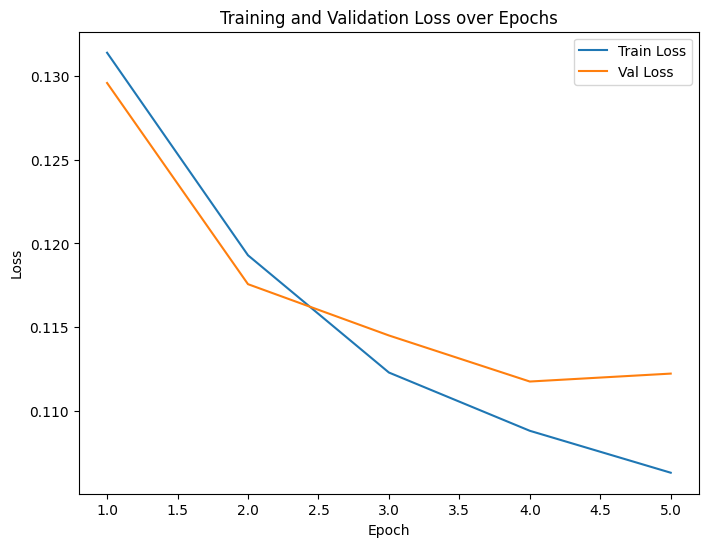

In [65]:
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Evaluate the prediction with the Pearson Correlation and explained variance.

In [66]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, responses in loader:
            preds = model(images)
            all_preds.append(preds.numpy())
            all_labels.append(responses.numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)

preds, labels = get_predictions(model, val_loader)

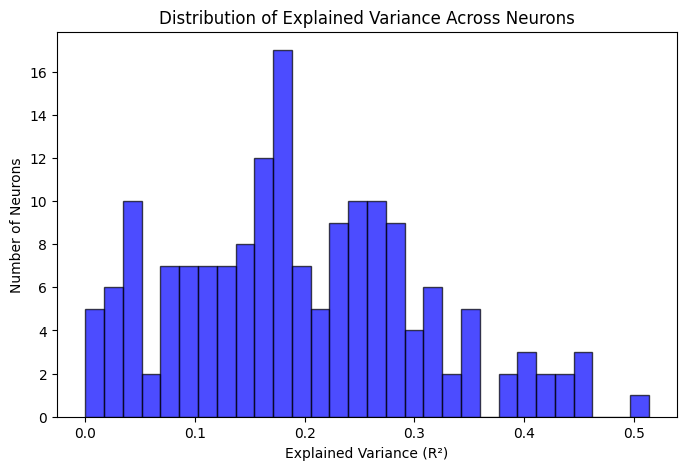

Mean Pearson correlation: 0.4211
Mean Explained Variance (R²): 0.1966


In [67]:
corrs = []
r_squared = []
for i in range(labels.shape[1]):
    corr, _ = pearsonr(preds[:, i], labels[:, i])
    corrs.append(corr)
    r_squared.append(corr ** 2)

mean_corr_cnn = np.mean(corrs)
mean_r_squared_cnn = np.mean(r_squared)

plt.figure(figsize=(8, 5))
plt.hist(r_squared, bins=30, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Explained Variance (R²)")
plt.ylabel("Number of Neurons")
plt.title("Distribution of Explained Variance Across Neurons")
plt.show()
print(f"Mean Pearson correlation: {mean_corr_cnn:.4f}")
print(f"Mean Explained Variance (R²): {mean_r_squared_cnn:.4f}")

We compare the results with those obtained in week 6. The shallow CNN predicts better than the linear models, but worse than the pretrained ResNet50.

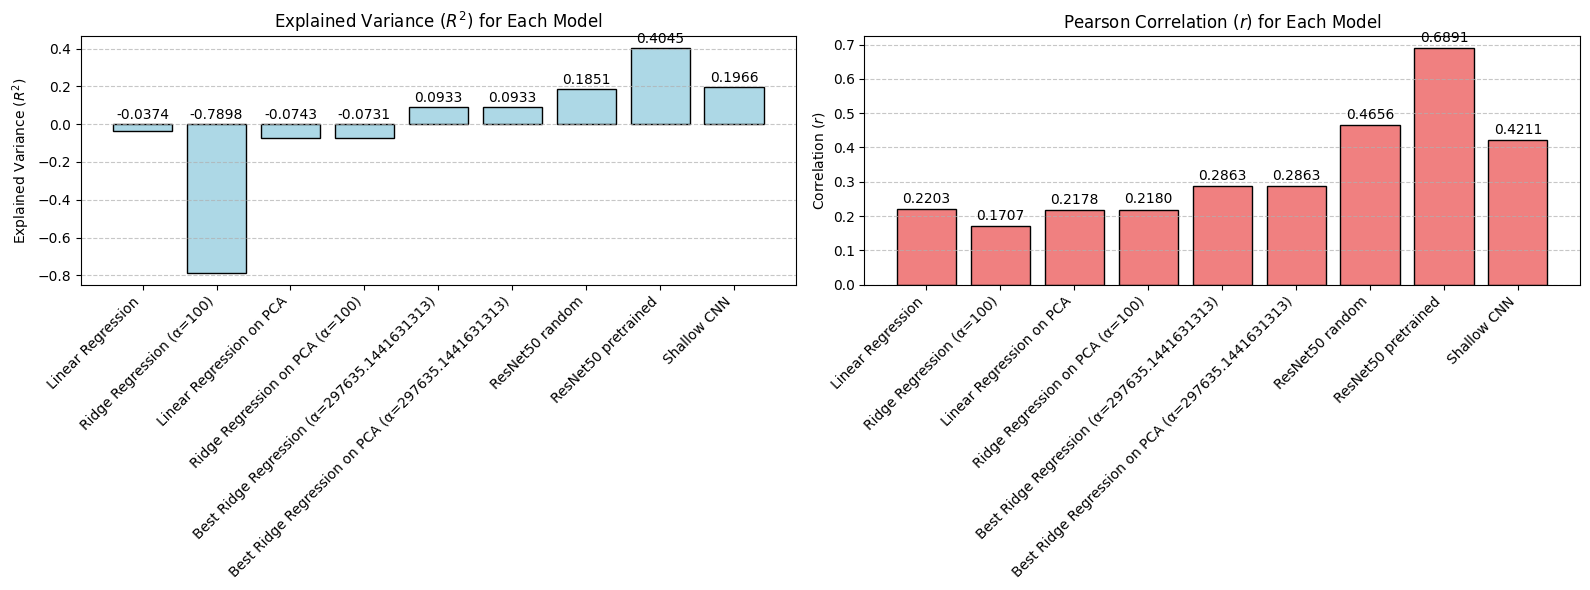

In [68]:
model_names_total.append('Shallow CNN')
all_variances_total.append(mean_r_squared_cnn)
all_correlations_total.append(mean_corr_cnn)
plot_comparison(model_names_total, all_variances_total, all_correlations_total)

# Week 8: Use different pretrained models

## First model: VGG16

First prepare the dataset.

In [69]:
# Convert numpy arrays to torch tensors
stimulus_train_torch = torch.tensor(stimulus_train).float()
stimulus_val_torch = torch.tensor(stimulus_val).float()

# Define normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Apply normalization
stim_train_torch = torch.stack([normalize(img) for img in stimulus_train_torch])
stim_val_torch = torch.stack([normalize(img) for img in stimulus_val_torch])

Then define the model, namely VGG16 where we take all layers expect the classifier and replace it to predict neural activity.

In [70]:
class VGG16_Finetune(nn.Module):
    def __init__(self, pretrained_model):
        super(VGG16_Finetune, self).__init__()
        self.features = pretrained_model.features
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, spikes_train.shape[1])
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Load the pretrained VGG16 model
vgg16_model = models.vgg16(pretrained=True)

# Fine-tune the model, where we modified the classifier
model_finetuned = VGG16_Finetune(vgg16_model)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_finetuned.to(device)

# DataLoader: Convert data to tensors and create DataLoader for batching
def create_dataloader(stimulus, spikes, batch_size):
    # Convert to TensorDataset and DataLoader for batching
    dataset = TensorDataset(stimulus, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# Define batch size, this will later be tuned
batch_size_train = 64
batch_size_val = 32

# Convert to tensors
stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

# Create dataloaders
train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model_finetuned.parameters(), lr=1e-4)

/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [71]:
# Number of epochs to train
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    model_finetuned.train()
    running_loss = 0.0
    for batch_input, batch_labels in train_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)

        # Steps defined above in the adapted Model
        optimizer.zero_grad()  # Zero the gradients
        outputs = model_finetuned(batch_input)  # Forward pass
        loss = criterion(outputs, batch_labels)  # Compute the loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update the weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")

Epoch [1/10], Loss: 0.1275
Epoch [2/10], Loss: 0.0991
Epoch [3/10], Loss: 0.0838
Epoch [4/10], Loss: 0.0718


Epoch [5/10], Loss: 0.0616
Epoch [6/10], Loss: 0.0530
Epoch [7/10], Loss: 0.0452
Epoch [8/10], Loss: 0.0388
Epoch [9/10], Loss: 0.0346
Epoch [10/10], Loss: 0.0311


We then evaluate the model on the validation set and compute the Pearson Correlation and the Explained Variance.

In [72]:
model_finetuned.eval()
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model_finetuned(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    pearson_corr_vgg16 = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
    print(f"Pearson Correlation: {pearson_corr_vgg16:.4f}")

    evs_vgg16 = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs_vgg16:.4f}")

Pearson Correlation: 0.6961
Explained Variance Score: 0.4088


Then, make a plot that shows the variation in neural prediction across layers of a task-driven model, in this case VGG16.

In [73]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook
    
conv_layer_indices = {
    "conv1_1": 0, "conv1_2": 2,
    "conv2_1": 5, "conv2_2": 7,
    "conv3_1": 10, "conv3_2": 12, "conv3_3": 14,
    "conv4_1": 17, "conv4_2": 19, "conv4_3": 21,
    "conv5_1": 24, "conv5_2": 26, "conv5_3": 28,
}

layer_names = list(conv_layer_indices.keys())

for name, idx in conv_layer_indices.items():
    model_finetuned.features[idx].register_forward_hook(get_activation(name))

model_finetuned.eval()

features_val = {name: [] for name in layer_names}
features_train = {name: [] for name in layer_names}
targets_val = []
targets_train = []

# For training
activations = {}

for images, spike_targets in train_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))
            flat = pooled.view(act.size(0), -1)
            features_train[name].append(flat.cpu())

        targets_train.append(spike_targets.cpu())

# For validation
for images, spike_targets in val_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))
            flat = pooled.view(act.size(0), -1)
            features_val[name].append(flat.cpu())

        targets_val.append(spike_targets.cpu())

# Finalize
for name in layer_names:
    features_train[name] = torch.cat(features_train[name]).numpy()
    features_val[name] = torch.cat(features_val[name]).numpy()
targets_train = torch.cat(targets_train).numpy()
targets_val = torch.cat(targets_val).numpy()

# Evaluate
r2_scores = []
pearson_rs = []

for name in layer_names:
    X_train = features_train[name]
    X_val = features_val[name]
    
    from sklearn.decomposition import PCA
    pca = PCA(n_components=100).fit(X_train)
    X_train = pca.transform(X_train)
    X_val = pca.transform(X_val)

    reg = Ridge(alpha=1.0)
    reg.fit(X_train, targets_train)

    preds = reg.predict(X_val)
    r2 = explained_variance_score(targets_val, preds)
    corr = np.corrcoef(targets_val.ravel(), preds.ravel())[0, 1]
    
    r2_scores.append(r2)
    pearson_rs.append(corr)

    print(f"{name}: R² = {r2:.3f}, Pearson r = {corr:.3f}")


conv1_1: R² = 0.168, Pearson r = 0.444
conv1_2: R² = 0.201, Pearson r = 0.479
conv2_1: R² = 0.243, Pearson r = 0.526
conv2_2: R² = 0.264, Pearson r = 0.547
conv3_1: R² = 0.267, Pearson r = 0.551
conv3_2: R² = 0.291, Pearson r = 0.572
conv3_3: R² = 0.330, Pearson r = 0.614
conv4_1: R² = 0.353, Pearson r = 0.637
conv4_2: R² = 0.359, Pearson r = 0.643
conv4_3: R² = 0.372, Pearson r = 0.654
conv5_1: R² = 0.382, Pearson r = 0.664
conv5_2: R² = 0.390, Pearson r = 0.672
conv5_3: R² = 0.386, Pearson r = 0.671


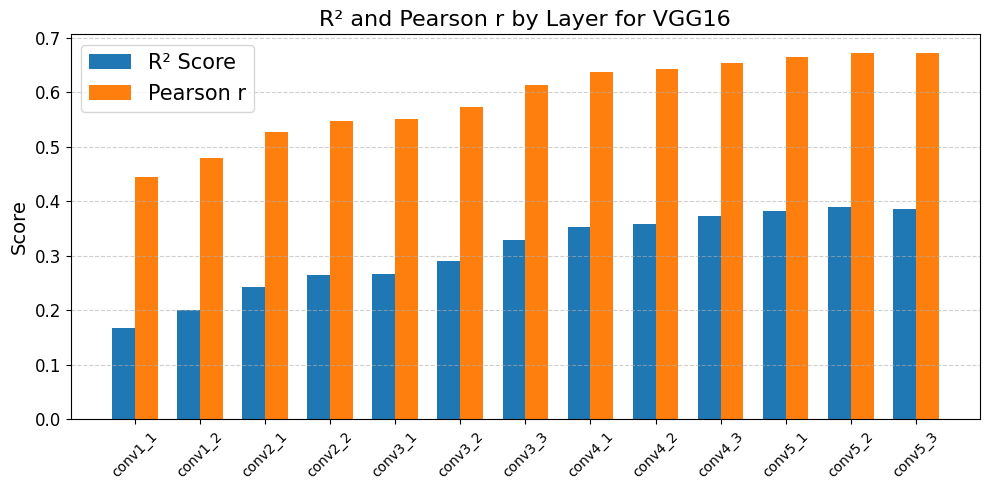

In [74]:
# Plot what we just obtained
x = np.arange(len(layer_names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
bar1 = ax1.bar(x - width/2, r2_scores, width, label='R² Score')
bar2 = ax1.bar(x + width/2, pearson_rs, width, label='Pearson r')

ax1.set_ylabel('Score', fontsize=14)
ax1.set_title('R² and Pearson r by Layer for VGG16', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=45, fontsize=12)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(fontsize=15)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.savefig("variation_across_layers.png", dpi=300)
plt.show()

We additionally decided to make a plot showing which layers of the model learn which features.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


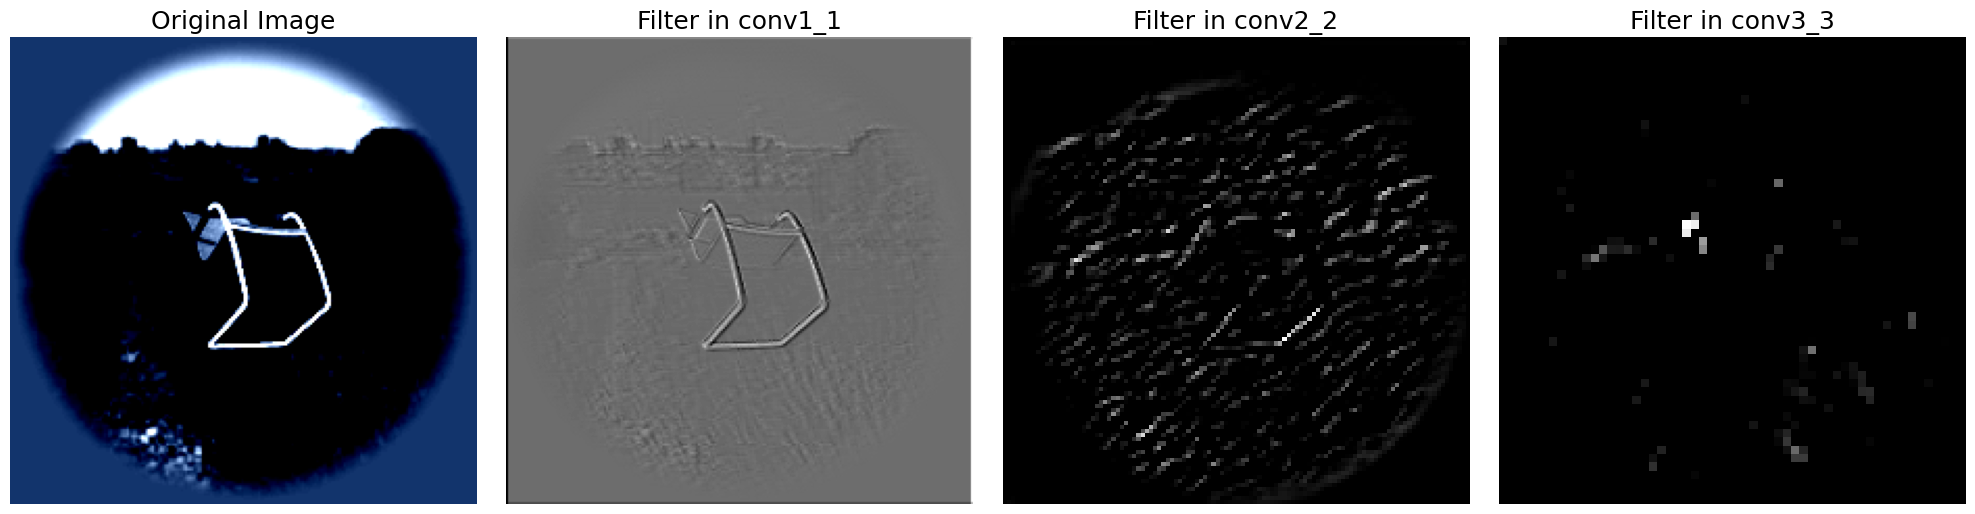

In [75]:
layer_names_plt2 = ['conv1_1', 'conv2_2', 'conv3_3']

fig, axes = plt.subplots(1, len(layer_names_plt2) + 1, figsize=(20, 5))
axes[0].imshow(images[0].cpu().numpy().transpose(1, 2, 0))
axes[0].set_title('Original Image', fontsize=18)
axes[0].axis('off')

# Loop over the layers and plot the first filter of each activation output
for idx, layer_name in enumerate(layer_names_plt2):
    activation_output = activations[layer_name]
    filter_img = activation_output[0, 0].cpu().numpy()
    axes[idx + 1].imshow(filter_img, cmap='gray')
    axes[idx + 1].set_title(f'Filter in {layer_name}', fontsize=18)
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()


Finally, we perform hyperparameter tuning on the VGG16 model to further improve its performance. We use Optune and define the objective function.

In [76]:
best_score_so_far = -float("inf")

def objective(trial):
    global best_score_so_far
    # Hyperparameter tuning for batch size train, batch size validation and learning rate
    batch_size_train = trial.suggest_int("batch_size_train", 16, 128, step=16)
    batch_size_val = trial.suggest_int("batch_size_val", 16, 128, step=16)
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)
    
    # Convert your stimuli and spikes to tensors (if not already)
    stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
    spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)
    
    # Create dataloaders
    train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
    val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)
    
    # Load the pretrained VGG16 model
    vgg16_model = models.vgg16(pretrained=True)
    model_finetuned = VGG16_Finetune(vgg16_model)
    
    # Move model to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_finetuned.to(device)
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_finetuned.parameters(), lr=lr)
    
    # Training loop
    num_epochs = 10
    for epoch in range(num_epochs):
        print(f"at epoch {epoch}")
        model_finetuned.train()
        running_loss = 0.0
        for batch_input, batch_labels in train_dataloader:
            batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model_finetuned(batch_input)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    # Evaluate the model on the validation set
    model_finetuned.eval()
    with torch.no_grad():
        val_outputs = []
        val_labels = []
        for batch_input, batch_labels in val_dataloader:
            batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
            outputs = model_finetuned(batch_input)
            val_outputs.append(outputs.cpu().numpy())
            val_labels.append(batch_labels.cpu().numpy())

        val_outputs = np.concatenate(val_outputs, axis=0)
        val_labels = np.concatenate(val_labels, axis=0)

        # Compute Pearson Correlation
        pearson_corr = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
        evs = explained_variance_score(val_labels, val_outputs)
        
        # Save model if it's the best so far
        if pearson_corr > best_score_so_far:
            best_score_so_far = pearson_corr

            # Save model
            save_path = './Documents/NX/NX-414-Project/best_vgg16_model.pth'
            torch.save({
                'model_state_dict': model_finetuned.state_dict(),
                'trial_params': trial.params,
            }, save_path)
            
            print(f"Saved new best model to: {os.path.abspath(save_path)} with Pearson = {pearson_corr:.4f}")

    return pearson_corr  # Optimize the pearson correlation

# Hyperparameter tuning using Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)
print("Best hyperparameters:", study.best_params)
print("Best value (Explained Variance Score):", study.best_value)

[I 2025-05-07 12:19:03,169] A new study created in memory with name: no-name-3015d535-c8a1-4aab-92a0-b66cce45295f
/tmp/2627177/ipykernel_2151558/2145912593.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. 

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-07 12:21:04,178] Trial 0 finished with value: -0.02354324118512531 and parameters: {'batch_size_train': 80, 'batch_size_val': 32, 'lr': 0.002550204333769717}. Best is trial 0 with value: -0.02354324118512531.


Saved new best model to: /home/vvoigt/Documents/NX/NX-414-Project/best_vgg16_model.pth with Pearson = -0.0235


/tmp/2627177/ipykernel_2151558/2145912593.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-07 12:58:56,322] Trial 18 finished with value: 0.7026419776107046 and parameters: {'batch_size_train': 16, 'batch_size_val': 64, 'lr': 2.0758049198191152e-05}. Best is trial 13 with value: 0.7138698059388985.
/tmp/2627177/ipykernel_2151558/2145912593.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be re

at epoch 0
at epoch 1
at epoch 2
at epoch 3
at epoch 4
at epoch 5
at epoch 6
at epoch 7
at epoch 8
at epoch 9


[I 2025-05-07 13:00:55,889] Trial 19 finished with value: 0.7033860522274061 and parameters: {'batch_size_train': 64, 'batch_size_val': 96, 'lr': 6.353077895574261e-05}. Best is trial 13 with value: 0.7138698059388985.


Best hyperparameters: {'batch_size_train': 16, 'batch_size_val': 48, 'lr': 4.184574506505141e-05}
Best value (Explained Variance Score): 0.7138698059388985


We then use the best model to make our final prediction.

In [77]:
best_params = study.best_params
batch_size_train = best_params["batch_size_train"]
batch_size_val = best_params["batch_size_val"]
learning_rate = best_params["lr"]

stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

def create_dataloader(stimulus, spikes, batch_size):
    dataset = TensorDataset(stimulus, spikes)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

# # Step 3: Load model and optimizer
vgg16_model = models.vgg16(pretrained=True)
model_finetuned = VGG16_Finetune(vgg16_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_finetuned.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_finetuned.parameters(), lr=learning_rate)

# Retrain the model with the best parameters
num_epochs = 10
for epoch in range(num_epochs):
    model_finetuned.train()
    running_loss = 0.0
    for batch_input, batch_labels in train_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        outputs = model_finetuned(batch_input)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")

# Evaluate it on the validation set
model_finetuned.eval()
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model_finetuned(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Pearson Correlation
    val_outputs_flat = val_outputs.flatten()
    val_labels_flat = val_labels.flatten()
    if np.std(val_outputs_flat) == 0 or np.std(val_labels_flat) == 0:
        pearson_corr_vgg16 = 0.0
    else:
        pearson_corr_vgg16, _ = pearsonr(val_outputs_flat, val_labels_flat)
    print(f"Pearson Correlation: {pearson_corr_vgg16:.4f}")

    # Explained Variance
    evs_vgg16 = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs_vgg16:.4f}")


/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10], Loss: 0.1126
Epoch [2/10], Loss: 0.0793
Epoch [3/10], Loss: 0.0612
Epoch [4/10], Loss: 0.0485
Epoch [5/10], Loss: 0.0393
Epoch [6/10], Loss: 0.0332
Epoch [7/10], Loss: 0.0292
Epoch [8/10], Loss: 0.0263
Epoch [9/10], Loss: 0.0241
Epoch [10/10], Loss: 0.0225
Pearson Correlation: 0.7105
Explained Variance Score: 0.4210


Compare VGG16 to the other models.

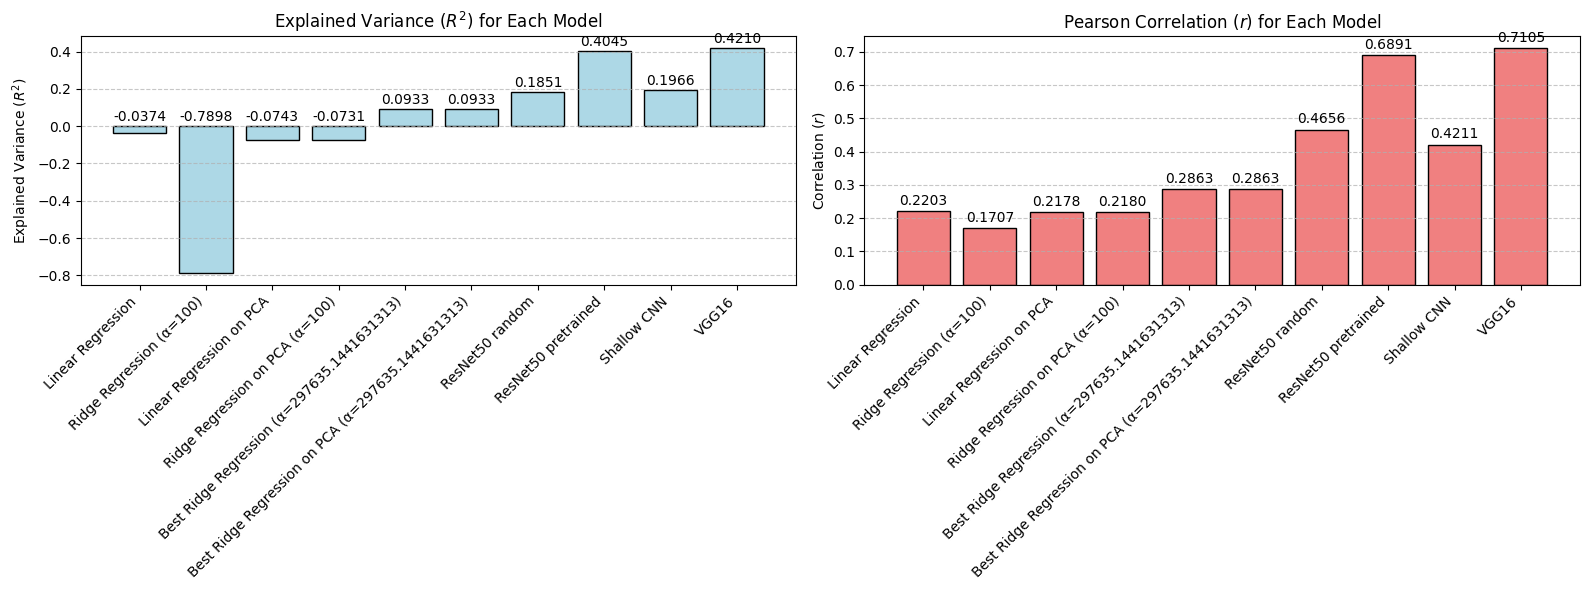

In [78]:
model_names_total.append('VGG16')
all_variances_total.append(evs_vgg16)
all_correlations_total.append(pearson_corr_vgg16)
plot_comparison(model_names_total, all_variances_total, all_correlations_total)

## Second model: VGG16 trained for object recognition while simultaneously predicting neural activity

We first define the multi-task model.

In [79]:
class VGG16_MultiTask(nn.Module):
    def __init__(self, pretrained_model, num_classes, num_neurons):
        super(VGG16_MultiTask, self).__init__()
        self.features = pretrained_model.features
    
        # Shared fully connected layer before branching
        self.shared_fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Task-specific heads
        self.classification_head = nn.Linear(4096, num_classes)  # for object recognition
        self.neural_head = nn.Linear(4096, num_neurons)           # for predicting neural spikes

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.shared_fc(x)
        
        class_output = self.classification_head(x)
        neural_output = self.neural_head(x)
        
        return class_output, neural_output

# Function to create dataloaders
def create_multitask_dataloader(stimulus, objects, spikes, batch_size):
    dataset = TensorDataset(stimulus, objects, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# Training function
def train_multitask_model(
    stimulus_train, objects_train, spikes_train,
    stimulus_val, objects_val, spikes_val,
    num_classes, num_neurons,
    learning_rate=1e-4,
    batch_size_train=64,
    batch_size_val=32,
    num_epochs=10,
    loss_weight_spikes=1.0
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Initialize the model
    pretrained_vgg = models.vgg16(pretrained=True)
    model = VGG16_MultiTask(pretrained_vgg, num_classes, num_neurons)
    model.to(device)

    # Prepare the data
    stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
    objects_train_tensor = torch.tensor(objects_train, dtype=torch.long)
    spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
    
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
    objects_val_tensor = torch.tensor(objects_val, dtype=torch.long)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

    train_loader = create_multitask_dataloader(stimulus_train_tensor, objects_train_tensor, spikes_train_tensor, batch_size_train)
    val_loader = create_multitask_dataloader(stimulus_val_tensor, objects_val_tensor, spikes_val_tensor, batch_size_val)

    # Losses
    criterion_classification = nn.CrossEntropyLoss()
    criterion_neural = nn.MSELoss()

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_input, batch_objects, batch_spikes in train_loader:
            batch_input, batch_objects, batch_spikes = batch_input.to(device), batch_objects.to(device), batch_spikes.to(device)

            optimizer.zero_grad()

            # Forward
            outputs_class, outputs_neural = model(batch_input)

            # Losses
            loss_class = criterion_classification(outputs_class, batch_objects)
            loss_neural = criterion_neural(outputs_neural, batch_spikes)

            # Total loss (you can adjust weighting)
            loss = loss_class + loss_weight_spikes * loss_neural

            # Backprop
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Combined Loss: {avg_loss:.4f}")

    return model


For the model to be able to use the objects, we need to One-Hot encode them so that the string becomes an int.

In [80]:
label_encoder = LabelEncoder()
objects_train_encoded = label_encoder.fit_transform(objects_train)
objects_val_encoded = label_encoder.transform(objects_val)

In [81]:
model_multitask = train_multitask_model(
    stimulus_train, objects_train_encoded, spikes_train,
    stimulus_val, objects_val_encoded, spikes_val,
    num_classes=len(label_encoder.classes_),
    num_neurons=spikes_train.shape[1], 
    learning_rate=1e-4,
    batch_size_train=128,
    batch_size_val=64,
    num_epochs=20,
    loss_weight_spikes=0.5
)

/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Combined Loss: 2.8853
Epoch [2/20], Combined Loss: 0.9026
Epoch [3/20], Combined Loss: 0.4509
Epoch [4/20], Combined Loss: 0.2709
Epoch [5/20], Combined Loss: 0.1696
Epoch [6/20], Combined Loss: 0.1288
Epoch [7/20], Combined Loss: 0.1090
Epoch [8/20], Combined Loss: 0.0951
Epoch [9/20], Combined Loss: 0.0861
Epoch [10/20], Combined Loss: 0.0784
Epoch [11/20], Combined Loss: 0.0722
Epoch [12/20], Combined Loss: 0.0668
Epoch [13/20], Combined Loss: 0.0624
Epoch [14/20], Combined Loss: 0.0582
Epoch [15/20], Combined Loss: 0.0545
Epoch [16/20], Combined Loss: 0.0518
Epoch [17/20], Combined Loss: 0.0490
Epoch [18/20], Combined Loss: 0.0463
Epoch [19/20], Combined Loss: 0.0440
Epoch [20/20], Combined Loss: 0.0420


In [82]:
def evaluate_multitask_model(model, stimulus_val, objects_val_encoded, spikes_val, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)
    
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32).to(device)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32).to(device)
    objects_val_tensor = torch.tensor(objects_val_encoded, dtype=torch.long).to(device)

    with torch.no_grad():
        outputs_object, outputs_spike = model(stimulus_val_tensor)

    # Move outputs to CPU
    outputs_spike = outputs_spike.cpu().numpy()
    spikes_val = spikes_val_tensor.cpu().numpy()

    outputs_object = outputs_object.cpu().numpy()
    objects_val = objects_val_tensor.cpu().numpy()

    # Evaluate for spike prediction
    n_neurons = spikes_val.shape[1]
    pearson_scores = []
    explained_var_scores = []

    for neuron_idx in range(n_neurons):
        pred = outputs_spike[:, neuron_idx]
        true = spikes_val[:, neuron_idx]

        # Pearson correlation
        if np.std(pred) > 0 and np.std(true) > 0:
            r, _ = pearsonr(pred, true)
        else:
            r = np.nan
        pearson_scores.append(r)

        # Explained variance
        ev = explained_variance_score(true, pred)
        explained_var_scores.append(ev)

    mean_pearson = np.nanmean(pearson_scores)
    mean_explained_variance = np.mean(explained_var_scores)

    # Evaluate for object recognition
    predicted_labels = np.argmax(outputs_object, axis=1)
    classification_accuracy = accuracy_score(objects_val, predicted_labels)

    print("Evaluation Results:")
    print(f"Spike prediction - Mean Pearson correlation: {mean_pearson:.4f}")
    print(f"Spike prediction - Mean Explained Variance: {mean_explained_variance:.4f}")
    print(f"Object recognition - Accuracy: {classification_accuracy * 100:.2f}%")

    return {
        'mean_pearson': mean_pearson,
        'mean_explained_variance': mean_explained_variance,
        'classification_accuracy': classification_accuracy
    }


In [83]:
metrics_VGG16_with_object = evaluate_multitask_model(model_multitask, stimulus_val, objects_val_encoded, spikes_val)

Evaluation Results:
Spike prediction - Mean Pearson correlation: 0.5490
Spike prediction - Mean Explained Variance: 0.2835
Object recognition - Accuracy: 84.03%


We then compare the object recognition model to the other models.

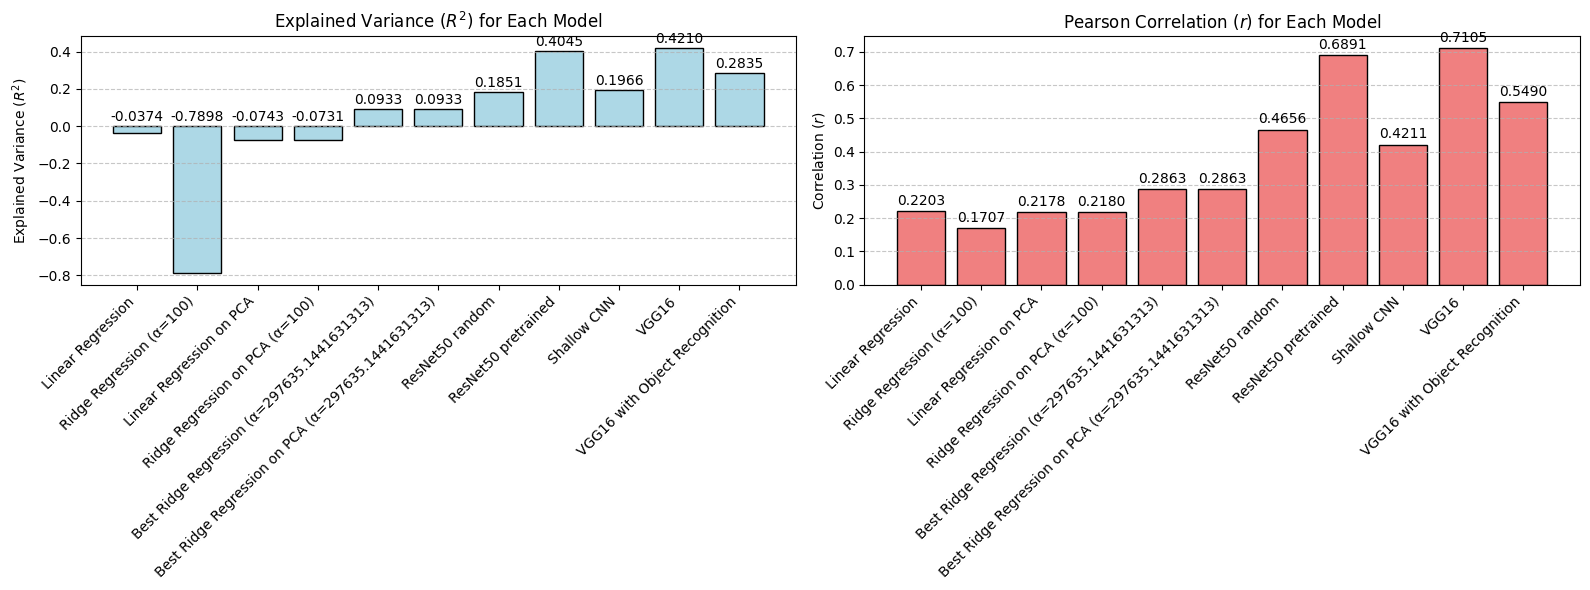

In [84]:
model_names_total.append('VGG16 with Object Recognition')
all_variances_total.append(metrics_VGG16_with_object['mean_explained_variance'])
all_correlations_total.append(metrics_VGG16_with_object['mean_pearson'])
plot_comparison(model_names_total, all_variances_total, all_correlations_total)

## Third model: Vision Transformer

In [85]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


Loading of pretrained ViT and normalization of stimuli

In [86]:
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
vit_model.reset_classifier(0)
vit_model = vit_model.to(device)
vit_model.eval()

stimulus_train_torch = torch.tensor(stimulus_train).float()
stimulus_val_torch = torch.tensor(stimulus_val).float()

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

stim_train_torch = torch.stack([normalize(img) for img in stimulus_train_torch])
stim_val_torch = torch.stack([normalize(img) for img in stimulus_val_torch])

In [87]:
def create_dataloader(stimulus, spikes, batch_size):
    # Convert to TensorDataset and DataLoader for batching
    dataset = TensorDataset(stimulus, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

batch_size_train = 64
batch_size_val = 32 

# Convert your stimuli and spikes to tensors (if not already)
stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

# Create dataloaders
train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

Hyperparamter tuning and training of model

In [88]:
param_grid = {
    'lr': [1e-3, 1e-4],
    'hidden_dim': [256, 512],
    'weight_decay': [1e-5, 1e-6],
    # 'lr': [1e-4],
    # 'hidden_dim': [256],
    # 'weight_decay': [1e-6],
}

best_loss = float('inf')
best_config = None

results = []

for lr, hidden_dim, wd in product(param_grid['lr'], param_grid['hidden_dim'], param_grid['weight_decay']):
    print(f"\n Tuning with: LR={lr}, Hidden={hidden_dim}, WeightDecay={wd}")
    set_seed(42)

    # Load pretrained ViT
    vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
    vit_model.reset_classifier(0)
    feature_dim = vit_model.num_features if hasattr(vit_model, 'num_features') else vit_model.embed_dim

    class ViTNeuralPredictor(nn.Module):
        def __init__(self, vit_model, feature_dim, output_dim=168):
            super(ViTNeuralPredictor, self).__init__()
            self.backbone = vit_model
            self.head = nn.Sequential(
                nn.Linear(feature_dim, 512),
                nn.ReLU(),
                nn.Linear(512, output_dim)
            )

        def forward(self, x):
            features = self.backbone(x)
            output = self.head(features)
            return output
        

    model = ViTNeuralPredictor(vit_model, feature_dim).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    NUM_EPOCHS = 10
    losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0

        for imgs, responses in train_dataloader:
            imgs = imgs.to(device)
            responses = responses.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, responses)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {avg_loss:.4f}")
        
    final_loss = losses[-1]
    results.append({'lr': lr, 'hidden_dim': hidden_dim, 'weight_decay': wd, 'final_loss': final_loss})

    if final_loss < best_loss:
        best_loss = final_loss
        best_config = {'lr': lr, 'hidden_dim': hidden_dim, 'weight_decay': wd}
    
        # Save the best model checkpoint
        torch.save({
            'model_state_dict': model.state_dict(),
            'vit_model_config': vit_model.default_cfg,
            'feature_dim': feature_dim,
            'best_config': best_config
        }, './Documents/NX/NX-414-Project/best_vit_model.pth')
        
save_path = os.path.abspath('best_vit_model.pth')
print(f"Saving best model to: {save_path}")
        
print("Grid Search Complete!")
print(f"Best configuration: {best_config} with loss: {best_loss:.4f}")

sorted_results = sorted(results, key=lambda x: x['final_loss'])
print("All configs ranked:")
for r in sorted_results:
    print(f"  LR={r['lr']}, Hidden={r['hidden_dim']}, WD={r['weight_decay']} → Loss={r['final_loss']:.4f}")


 Tuning with: LR=0.001, Hidden=256, WeightDecay=1e-05
Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1330
Epoch [3/10] - Train Loss: 0.1286
Epoch [4/10] - Train Loss: 0.1181
Epoch [5/10] - Train Loss: 0.1022
Epoch [6/10] - Train Loss: 0.0888
Epoch [7/10] - Train Loss: 0.0779
Epoch [8/10] - Train Loss: 0.0678
Epoch [9/10] - Train Loss: 0.0594
Epoch [10/10] - Train Loss: 0.0521

 Tuning with: LR=0.001, Hidden=256, WeightDecay=1e-06
Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1324
Epoch [3/10] - Train Loss: 0.1254
Epoch [4/10] - Train Loss: 0.1147
Epoch [5/10] - Train Loss: 0.1001
Epoch [6/10] - Train Loss: 0.0881
Epoch [7/10] - Train Loss: 0.0797
Epoch [8/10] - Train Loss: 0.0709
Epoch [9/10] - Train Loss: 0.0631
Epoch [10/10] - Train Loss: 0.0551

 Tuning with: LR=0.001, Hidden=512, WeightDecay=1e-05
Epoch [1/10] - Train Loss: 0.1397
Epoch [2/10] - Train Loss: 0.1326
Epoch [3/10] - Train Loss: 0.1270
Epoch [4/10] - Train Loss: 0.1164
Epoch [5/10] - Tr

Load and define best ViT model

In [89]:
checkpoint = torch.load("best_vit_model.pth", map_location=device)

# Load pretrained backbone
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
vit_model.reset_classifier(0)  # remove classification head

# Rebuild and load full model
feature_dim = checkpoint['feature_dim']
model = ViTNeuralPredictor(vit_model, feature_dim).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

ViTNeuralPredictor(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximat

Run best model on validation set

In [90]:
# Evaluate the model on the validation set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Compute Pearson Correlation
    pearson_corr_vit = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
    print(f"Pearson Correlation: {pearson_corr_vit:.4f}")

    # Compute Explained Variance Score
    evs_vit = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs_vit:.4f}")

Pearson Correlation: 0.6843
Explained Variance Score: 0.3959


Append best model to visualization plot

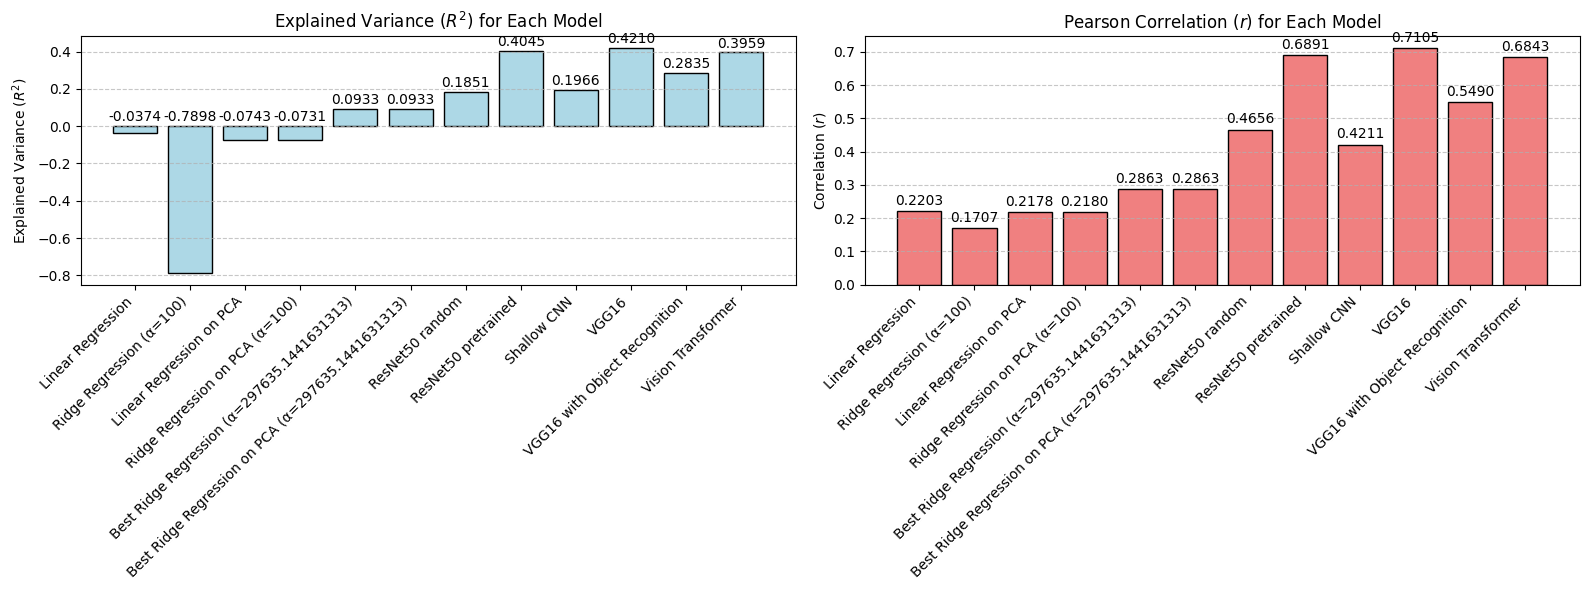

In [91]:
model_names_total.append('Vision Transformer')
all_variances_total.append(evs_vit)
all_correlations_total.append(pearson_corr_vit)
plot_comparison(model_names_total, all_variances_total, all_correlations_total)